In [ ]:
# =============================================================================
# Competitive Frontier & Volatility Tercile Analysis
# =============================================================================
# Shows that model gains concentrate where volatility/competition is high.
# Uses a mean-CPC x volatility quadrant ("competitive frontier") and
# volatility terciles to segment keywords and report per-segment metrics.
# =============================================================================

import os
import json
import torch
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# -- Paths (local) ---------------------------------------------------------
TENSOR_ROOT = "results/tensors"
TIME_SERIES_PATH = "/data/sem_dtw_geo_enriched_dummies.parquet"
KEYWORD_MAP_PATH = "/Users/edoardobeccari/Documents/GitHub/master_thesis/data/sebs_keyword_graph_knn/keyword_map.json"
OUTPUT_DIR = "results/output"

TARGET_COL = 'cpc_week'
TEST_WEEKS_LAST = 12
VAL_RATIO = 0.25
NUM_NODES = 1811

os.makedirs(OUTPUT_DIR, exist_ok=True)

def output_path(filename):
    return os.path.join(OUTPUT_DIR, filename)

plt.rcParams.update({
    'figure.figsize': (12, 7), 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 12,
})

In [30]:
# =============================================================================
# Load data & keyword map, compute per-keyword CPC statistics
# =============================================================================

df = pd.read_parquet(TIME_SERIES_PATH)
print(f"Loaded parquet: {df.shape}")

# Parse weeks to numeric YYYYWW
if df['week'].dtype == object:
    parts = df['week'].astype(str).str.split('-', expand=True)
    df['week_num'] = pd.to_numeric(parts[1]) * 100 + pd.to_numeric(parts[0])
else:
    df['week_num'] = pd.to_numeric(df['week'])

# Load keyword map (keyword string → node index)
with open(KEYWORD_MAP_PATH, 'r') as f:
    keyword_map = json.load(f)
idx_to_keyword = {v: k for k, v in keyword_map.items()}
print(f"Keyword map: {len(keyword_map)} keywords")

# ── Per-keyword statistics on RAW CPC ──────────────────────────────────────
keyword_stats = (
    df.groupby('keyword')[TARGET_COL]
    .agg(['mean', 'std', 'median', 'count'])
    .rename(columns={'mean': 'mean_cpc', 'std': 'std_cpc',
                      'median': 'median_cpc', 'count': 'n_weeks'})
)

# Coefficient of variation = normalised volatility
keyword_stats['cv_cpc'] = keyword_stats['std_cpc'] / (keyword_stats['mean_cpc'] + 1e-8)

# Week-over-week absolute change as alternative volatility measure
wow_vol = (
    df.sort_values(['keyword', 'week_num'])
    .groupby('keyword')[TARGET_COL]
    .apply(lambda s: s.diff().abs().mean())
    .rename('wow_volatility')
)
keyword_stats = keyword_stats.join(wow_vol)

# Attach node indices
keyword_stats['node_idx'] = keyword_stats.index.map(keyword_map)
keyword_stats = keyword_stats.dropna(subset=['node_idx'])
keyword_stats['node_idx'] = keyword_stats['node_idx'].astype(int)

print(f"\nKeyword stats computed for {len(keyword_stats)} keywords")
print(keyword_stats.describe().round(4))

Loaded parquet: (218924, 404)
Keyword map: 1811 keywords

Keyword stats computed for 1811 keywords
        mean_cpc    std_cpc  median_cpc    n_weeks     cv_cpc  wow_volatility  \
count  1811.0000  1811.0000   1811.0000  1811.0000  1811.0000       1811.0000   
mean      2.7469     1.3936      2.4920   120.8857     0.5137          0.9128   
std       1.7041     1.0389      1.5140     5.5229     0.1583          0.6639   
min       0.3289     0.1687      0.2674   110.0000     0.1537          0.0418   
25%       1.4292     0.7415      1.2656   116.0000     0.4071          0.4711   
50%       2.4244     1.1593      2.2029   122.0000     0.4890          0.7503   
75%       3.5637     1.7330      3.3003   126.0000     0.5892          1.1684   
max      14.7445    11.6340      9.6036   127.0000     1.7797          5.7623   

       node_idx  
count  1811.000  
mean    905.000  
std     522.935  
min       0.000  
25%     452.500  
50%     905.000  
75%    1357.500  
max    1810.000  


In [31]:
# =============================================================================
# Define volatility terciles and competitive frontier quadrants
# =============================================================================

# --- Volatility Terciles (based on CV) ---
keyword_stats['vol_tercile'] = pd.qcut(
    keyword_stats['cv_cpc'], q=3, labels=['Low', 'Medium', 'High']
)

# --- Competitive Frontier Quadrants (mean-CPC x volatility) ---
med_mean = keyword_stats['mean_cpc'].median()
med_vol  = keyword_stats['cv_cpc'].median()

def assign_quadrant(row):
    high_cpc = row['mean_cpc'] >= med_mean
    high_vol = row['cv_cpc']   >= med_vol
    if high_cpc and high_vol:       return 'High CPC / High Vol'
    elif high_cpc and not high_vol: return 'High CPC / Low Vol'
    elif not high_cpc and high_vol: return 'Low CPC / High Vol'
    else:                           return 'Low CPC / Low Vol'

keyword_stats['quadrant'] = keyword_stats.apply(assign_quadrant, axis=1)

# Lookup dicts: node_idx -> segment
node_to_tercile  = keyword_stats.set_index('node_idx')['vol_tercile'].to_dict()
node_to_quadrant = keyword_stats.set_index('node_idx')['quadrant'].to_dict()

print("=== Volatility Tercile Distribution ===")
print(keyword_stats['vol_tercile'].value_counts().sort_index())
print(f"\n=== Competitive Frontier Quadrant Distribution ===")
print(keyword_stats['quadrant'].value_counts())
print(f"\nMedian thresholds: mean_cpc={med_mean:.4f}, cv_cpc={med_vol:.4f}")

=== Volatility Tercile Distribution ===
vol_tercile
Low       604
Medium    603
High      604
Name: count, dtype: int64

=== Competitive Frontier Quadrant Distribution ===
quadrant
Low CPC / High Vol     504
High CPC / Low Vol     504
High CPC / High Vol    402
Low CPC / Low Vol      401
Name: count, dtype: int64

Median thresholds: mean_cpc=2.4244, cv_cpc=0.4890


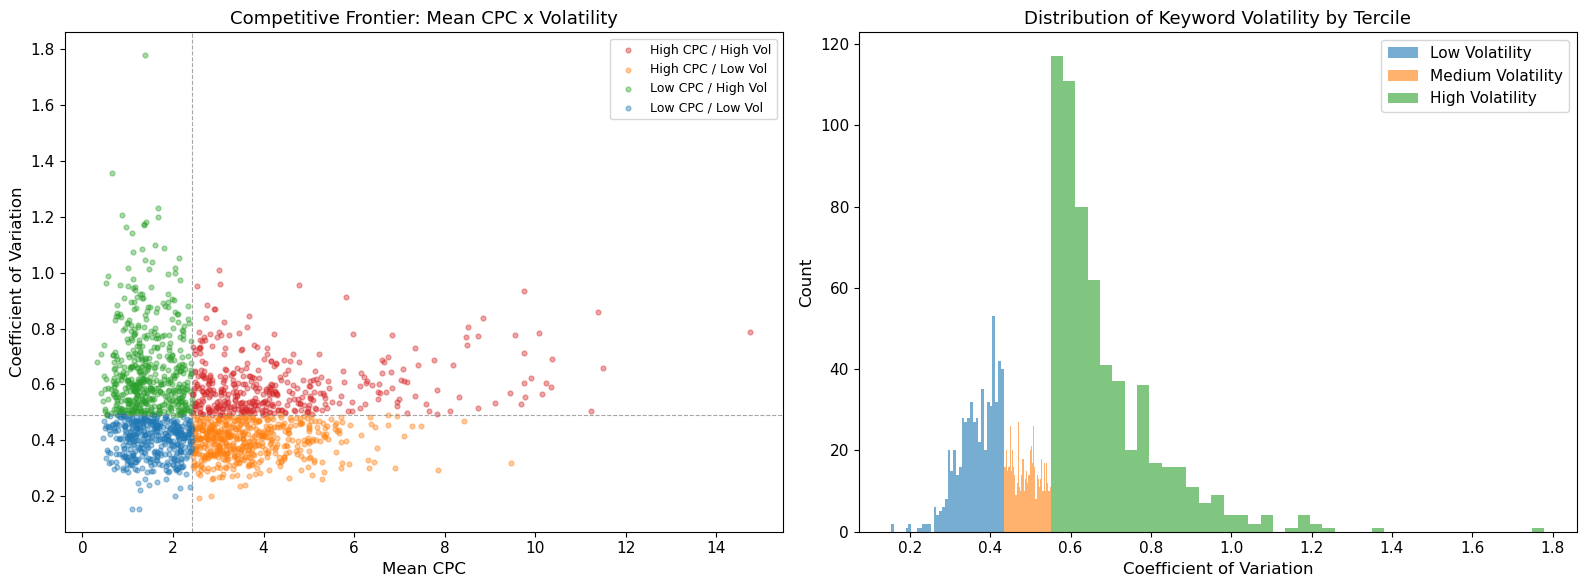

Saved: output/competitive_frontier_scatter.pdf


In [32]:
# =============================================================================
# Visualize the competitive frontier scatter
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Quadrant scatter ---
ax = axes[0]
colors_q = {
    'High CPC / High Vol': '#d62728',
    'High CPC / Low Vol':  '#ff7f0e',
    'Low CPC / High Vol':  '#2ca02c',
    'Low CPC / Low Vol':   '#1f77b4',
}
for quad, grp in keyword_stats.groupby('quadrant'):
    ax.scatter(grp['mean_cpc'], grp['cv_cpc'], alpha=0.4, s=12,
               label=quad, color=colors_q[quad])
ax.axvline(med_mean, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.axhline(med_vol, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.set_xlabel('Mean CPC')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Competitive Frontier: Mean CPC x Volatility')
ax.legend(fontsize=9, loc='upper right')

# --- Tercile histogram ---
ax2 = axes[1]
for terc in ['Low', 'Medium', 'High']:
    subset = keyword_stats[keyword_stats['vol_tercile'] == terc]
    ax2.hist(subset['cv_cpc'], bins=40, alpha=0.6, label=f'{terc} Volatility')
ax2.set_xlabel('Coefficient of Variation')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Keyword Volatility by Tercile')
ax2.legend()

figure_path = output_path('competitive_frontier_scatter.pdf')
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

In [33]:
# =============================================================================
# Universal CPC scaler + Helper functions
# =============================================================================
# KEY INSIGHT: StandardScaler fits each column independently.
# The mean & std of log1p(cpc_week) are IDENTICAL regardless of which other
# features were in the scaler during training.  So we compute them once from
# the local parquet (same CPC series, same week split) and use them for
# ALL experiments.
# =============================================================================

# --- Compute universal CPC scaler stats ---
weeks = np.array(sorted(df['week_num'].unique()))
trainval_weeks = weeks[:-TEST_WEEKS_LAST]
split_idx = int(len(trainval_weeks) * (1 - VAL_RATIO))
train_weeks = trainval_weeks[:split_idx]

cpc_train = df[df['week_num'].isin(train_weeks)][TARGET_COL].values.astype(np.float32)
cpc_train_log = np.log1p(cpc_train)
CPC_MEAN = cpc_train_log.mean()
CPC_STD  = cpc_train_log.std()

print(f"Week split: {len(train_weeks)} train, "
      f"{len(trainval_weeks) - len(train_weeks)} val, {TEST_WEEKS_LAST} test")
print(f"Universal CPC scaler: mean(log1p) = {CPC_MEAN:.6f}, std(log1p) = {CPC_STD:.6f}")


def inverse_transform_cpc(scaled_values):
    """Convert scaled log-CPC predictions/targets back to original CPC scale."""
    if isinstance(scaled_values, torch.Tensor):
        scaled_values = scaled_values.cpu().numpy()
    real = np.expm1(scaled_values.astype(np.float64) * CPC_STD + CPC_MEAN)
    return np.maximum(real, 0.0)


def compute_segment_metrics(preds, targets, node_indices):
    """
    Compute RMSE, MAE, sMAPE for a subset of nodes.
    preds, targets: [num_samples, num_nodes] in original CPC scale
    node_indices: array of node indices to evaluate
    """
    p = preds[:, node_indices]
    t = targets[:, node_indices]

    rmse = np.sqrt(np.mean((p - t) ** 2))
    mae  = np.mean(np.abs(p - t))

    # sMAPE: symmetric mean absolute percentage error
    num = np.abs(p - t)
    den = (np.abs(p) + np.abs(t)) / 2.0
    smape = 100.0 * np.mean(num / (den + 1e-8))

    # Per-node RMSE distribution
    node_rmse = np.sqrt(np.mean((p - t) ** 2, axis=0))

    return {
        'RMSE': rmse, 'MAE': mae, 'sMAPE': smape,
        'med_node_RMSE': np.median(node_rmse),
        'n_keywords': len(node_indices),
    }


def find_tensor_pairs(exp_dir, exp_name=None):
    """
    Find all (model, horizon, pred_path, target_path) in a directory.
    Handles both naming conventions:
      - exp1/exp2: {Model}_h{H}_predictions.pt
      - ablation:  {Model}_{exp_name}_h{H}_predictions.pt
    """
    all_files = set(os.listdir(exp_dir))
    pred_files = sorted(f for f in all_files if f.endswith('_predictions.pt'))
    results = []
    for pf in pred_files:
        tf = pf.replace('_predictions.pt', '_targets.pt')
        if tf not in all_files:
            continue

        # Strip suffix and parse
        base = pf.replace('_predictions.pt', '')

        # Try to extract horizon from the end: ..._h{H}
        m = re.match(r'^(.+)_h(\d+)$', base)
        if not m:
            continue
        prefix, horizon = m.group(1), int(m.group(2))

        # Remove experiment name suffix if present to get clean model name
        model_name = prefix
        if exp_name and prefix.endswith(f'_{exp_name}'):
            model_name = prefix[: -len(f'_{exp_name}')]

        results.append((model_name, horizon,
                        os.path.join(exp_dir, pf),
                        os.path.join(exp_dir, tf)))
    return results


print("Helper functions defined.")

Week split: 86 train, 29 val, 12 test
Universal CPC scaler: mean(log1p) = 1.126434, std(log1p) = 0.517456
Helper functions defined.


In [34]:
# =============================================================================
# Build node index arrays for each segment
# =============================================================================

# Tercile node indices
tercile_nodes = {}
for terc in ['Low', 'Medium', 'High']:
    nodes = keyword_stats[keyword_stats['vol_tercile'] == terc]['node_idx'].values
    tercile_nodes[terc] = np.sort(nodes)
    print(f"Tercile '{terc}': {len(nodes)} keywords")

# Quadrant node indices
quadrant_order = ['Low CPC / Low Vol', 'Low CPC / High Vol',
                  'High CPC / Low Vol', 'High CPC / High Vol']
quadrant_nodes = {}
for quad in quadrant_order:
    nodes = keyword_stats[keyword_stats['quadrant'] == quad]['node_idx'].values
    quadrant_nodes[quad] = np.sort(nodes)
    print(f"Quadrant '{quad}': {len(nodes)} keywords")

# All nodes for reference
all_nodes = np.arange(NUM_NODES)

Tercile 'Low': 604 keywords
Tercile 'Medium': 603 keywords
Tercile 'High': 604 keywords
Quadrant 'Low CPC / Low Vol': 401 keywords
Quadrant 'Low CPC / High Vol': 504 keywords
Quadrant 'High CPC / Low Vol': 504 keywords
Quadrant 'High CPC / High Vol': 402 keywords


In [35]:
# =============================================================================
# Process ALL experiment tensors -> segment-wise metrics
# =============================================================================
# Layout:
#   tensors/exp1_tensors/          -> {Model}_h{H}_*.pt
#   tensors/exp2_tensors/          -> {Model}_h{H}_*.pt
#   tensors/exp3_tensors/exp_{X}/  -> {Model}_{X}_h{H}_*.pt
#   tensors/ablation_tensors/exp_{X}/  -> {Model}_{X}_h{H}_*.pt
#   tensors/ablation2_tensors/exp_{X}/ -> {Model}_{X}_h{H}_*.pt
# =============================================================================

all_results = []

for group_name in sorted(os.listdir(TENSOR_ROOT)):
    group_path = os.path.join(TENSOR_ROOT, group_name)
    if not os.path.isdir(group_path) or group_name.startswith('.'):
        continue

    # Decide if this is a flat dir (has .pt files) or nested (has sub-experiment dirs)
    has_pt = any(f.endswith('.pt') for f in os.listdir(group_path))

    if has_pt:
        # Flat experiment: e.g. exp1_tensors/
        sub_experiments = {group_name: group_path}
    else:
        # Nested: e.g. ablation_tensors/exp_core_only/ ...
        sub_experiments = {}
        for sub in sorted(os.listdir(group_path)):
            sub_path = os.path.join(group_path, sub)
            if os.path.isdir(sub_path) and not sub.startswith('.'):
                sub_experiments[sub] = sub_path

    for exp_name, exp_dir in sub_experiments.items():
        # Derive clean experiment label (strip 'exp_' prefix if present)
        exp_label = exp_name.replace('exp_', '') if exp_name.startswith('exp_') else exp_name

        pairs = find_tensor_pairs(exp_dir, exp_name=exp_label)
        if not pairs:
            continue

        print(f"[{group_name}/{exp_name}] {len(pairs)} tensor pairs")

        for model_name, horizon, pred_path, tgt_path in pairs:
            try:
                preds_t = torch.load(pred_path, map_location='cpu', weights_only=True)
                tgts_t  = torch.load(tgt_path,  map_location='cpu', weights_only=True)

                # Inverse transform: scaled log-CPC -> original CPC
                real_preds   = inverse_transform_cpc(preds_t)
                real_targets = inverse_transform_cpc(tgts_t)

                # Reshape to [num_samples, NUM_NODES]
                real_preds   = real_preds.reshape(-1, NUM_NODES)
                real_targets = real_targets.reshape(-1, NUM_NODES)

                row_base = {
                    'exp_group': group_name,
                    'experiment': exp_label,
                    'model': model_name,
                    'horizon': horizon,
                }

                # Overall
                m = compute_segment_metrics(real_preds, real_targets, all_nodes)
                all_results.append({**row_base, 'seg_type': 'overall', 'segment': 'All', **m})

                # Tercile
                for t_name, t_idx in tercile_nodes.items():
                    m = compute_segment_metrics(real_preds, real_targets, t_idx)
                    all_results.append({**row_base, 'seg_type': 'tercile', 'segment': t_name, **m})

                # Quadrant
                for q_name, q_idx in quadrant_nodes.items():
                    m = compute_segment_metrics(real_preds, real_targets, q_idx)
                    all_results.append({**row_base, 'seg_type': 'quadrant', 'segment': q_name, **m})

            except Exception as e:
                print(f"  ERROR {model_name} h{horizon}: {e}")

df_results = pd.DataFrame(all_results)
df_results.to_csv('competitive_frontier_results.csv', index=False)
print(f"\nTotal rows: {len(df_results)}")
print(f"Exp groups: {df_results['exp_group'].unique().tolist()}")
print(f"Models: {sorted(df_results['model'].unique())}")
print("Saved: competitive_frontier_results.csv")

[ablation2_tensors/exp_core_geo_search] 12 tensor pairs
[ablation2_tensors/exp_core_geo_sem_pc] 12 tensor pairs
[ablation_tensors/exp_all_features] 12 tensor pairs
[ablation_tensors/exp_core_dom] 12 tensor pairs
[ablation_tensors/exp_core_dtw] 10 tensor pairs
[ablation_tensors/exp_core_geo] 12 tensor pairs
[ablation_tensors/exp_core_lags] 12 tensor pairs
[ablation_tensors/exp_core_only] 9 tensor pairs
[ablation_tensors/exp_core_search] 10 tensor pairs
[ablation_tensors/exp_core_sem_pc] 10 tensor pairs
[ablation_tensors/exp_core_sim25] 12 tensor pairs
[exp1_tensors/exp1_tensors] 22 tensor pairs
[exp2_tensors/exp2_tensors] 24 tensor pairs
[exp3_tensors/exp_core_city] 10 tensor pairs
[exp3_tensors/exp_core_continent] 12 tensor pairs
[exp3_tensors/exp_core_continent_search] 12 tensor pairs
[exp3_tensors/exp_core_continent_sempc] 11 tensor pairs
[exp3_tensors/exp_core_country] 10 tensor pairs
[exp3_tensors/exp_core_country_search] 11 tensor pairs

Total rows: 1880
Exp groups: ['ablation2_te

In [36]:
# =============================================================================
# Feature Set Mapping & Labelling
# =============================================================================
# Map every experiment label to a human-readable feature-set name.
# The ablation experiments follow `core_<feature>` convention.
# exp1/exp2 = "all_features" (the full dataset used in the main experiment).
# Benchmarks will be handled separately later.
# =============================================================================

# Human-readable labels for each feature set
FEATURE_SET_LABELS = {
    'core_only':        'Core (CPC only)',
    'core_lags':        'Core + Lags',
    'core_search':      'Core + Search',
    'core_dom':         'Core + Domain',
    'core_dtw':         'Core + DTW',
    'core_geo':         'Core + Geo',
    'core_sem_pc':      'Core + Sem PC',
    'core_sim25':       'Core + Sim25',
    'all_features':     'All Features',
    # Combination sets (ablation2)
    'core_geo_search':  'Core + Geo + Search',
    'core_geo_sem_pc':  'Core + Geo + Sem PC',
    # Geo granularity (exp3)
    'core_city':              'Core + City',
    'core_country':           'Core + Country',
    'core_continent':         'Core + Continent',
    'core_country_search':    'Core + Country + Search',
    'core_continent_search':  'Core + Continent + Search',
    'core_continent_sempc':   'Core + Continent + Sem PC',
}

# Map exp1/exp2 to "all_features" since those are the full-feature runs
def map_feature_set(row):
    exp = row['experiment']
    eg  = row['exp_group']
    if eg in ('exp1_tensors', 'exp2_tensors'):
        return 'all_features'
    return exp

df_results['feature_set'] = df_results.apply(map_feature_set, axis=1)
df_results['feature_set_label'] = df_results['feature_set'].map(FEATURE_SET_LABELS).fillna(df_results['feature_set'])

# --- Define analysis subsets (for reference / grouping) ---
# Single-feature ablation sets
ABLATION_SETS = ['core_only', 'core_lags', 'core_search', 'core_dom',
                 'core_dtw', 'core_geo', 'core_sem_pc', 'core_sim25', 'all_features']
# Combination sets (ablation2)
COMBO_SETS = ['core_geo_search', 'core_geo_sem_pc']
# Geo granularity (exp3)
GEO_SETS = ['core_city', 'core_country', 'core_continent',
            'core_country_search', 'core_continent_search', 'core_continent_sempc']

# --- Use ALL GNN experiments (everything from tensors), not just ablation subset ---
abl_df = df_results.copy()

# Stable ordering: core_only first, single-feature ablations, combos, geo, all_features last
_all_fs = sorted(abl_df['feature_set'].unique())
_single = sorted([s for s in ABLATION_SETS if s not in ('core_only', 'all_features') and s in _all_fs])
_combo  = sorted([s for s in COMBO_SETS if s in _all_fs])
_geo    = sorted([s for s in GEO_SETS if s in _all_fs])
_other  = sorted([s for s in _all_fs if s not in ABLATION_SETS + COMBO_SETS + GEO_SETS])
set_order = (
    (['core_only'] if 'core_only' in _all_fs else [])
    + _single + _combo + _geo + _other
    + (['all_features'] if 'all_features' in _all_fs else [])
)

print(f"Feature sets in df_results ({len(set_order)} total): {set_order}")
print(f"\nAnalysis rows: {len(abl_df)}")
print(f"  Models: {sorted(abl_df['model'].unique())}")
print(f"  Horizons: {sorted(abl_df['horizon'].unique())}")

Feature sets in df_results (17 total): ['core_only', 'core_dom', 'core_dtw', 'core_geo', 'core_lags', 'core_search', 'core_sem_pc', 'core_sim25', 'core_geo_search', 'core_geo_sem_pc', 'core_city', 'core_continent', 'core_continent_search', 'core_continent_sempc', 'core_country', 'core_country_search', 'all_features']

Analysis rows: 1880
  Models: ['A3TGCN', 'AGCRN', 'DCRNN', 'GConvLSTM', 'GraphWaveNet', 'MTGNN', 'STConv', 'STGCN']
  Horizons: [np.int64(1), np.int64(6), np.int64(12)]


In [37]:
# =============================================================================
# TABLE 1: Feature Set Comparison — averaged across GNN architectures
# =============================================================================
# PRIMARY analysis axis: how does each feature set perform by volatility
# segment?  We average across models to isolate the feature-set effect.
# =============================================================================

abl_terc = abl_df[abl_df['seg_type'] == 'tercile']
abl_overall = abl_df[abl_df['seg_type'] == 'overall']

print("=" * 80)
print("TABLE 1: Feature Set Performance by Volatility Tercile (avg across models)")
print("=" * 80)

for metric in ['sMAPE', 'RMSE']:
    print(f"\n{'─'*80}")
    print(f"  Metric: {metric}")
    print(f"{'─'*80}")
    for h in sorted(abl_terc['horizon'].unique()):
        print(f"\n  Horizon h={h}")
        sub_t = abl_terc[abl_terc['horizon'] == h]
        sub_o = abl_overall[abl_overall['horizon'] == h]

        # Pivot: feature_set × tercile, averaged over models
        pivot = sub_t.pivot_table(
            index='feature_set', columns='segment',
            values=metric, aggfunc='mean'
        )
        cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
        pivot = pivot[cols]

        # Add overall column
        ov = sub_o.groupby('feature_set')[metric].mean()
        pivot['Overall'] = ov

        # High/Low ratio
        if 'High' in pivot.columns and 'Low' in pivot.columns:
            pivot['High/Low'] = (pivot['High'] / pivot['Low']).round(2)

        # Map to readable labels
        pivot.index = pivot.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))
        print(pivot.round(2).to_string())

TABLE 1: Feature Set Performance by Volatility Tercile (avg across models)

────────────────────────────────────────────────────────────────────────────────
  Metric: sMAPE
────────────────────────────────────────────────────────────────────────────────

  Horizon h=1
segment                      Low  Medium   High  Overall  High/Low
feature_set                                                       
All Features               21.09   28.34  38.34    29.26      1.82
Core + City                18.32   26.52  36.07    26.97      1.97
Core + Continent           17.69   25.78  35.62    26.36      2.01
Core + Continent + Search  17.94   25.75  35.55    26.41      1.98
Core + Continent + Sem PC  17.92   25.89  35.72    26.51      1.99
Core + Country             18.16   25.93  35.77    26.62      1.97
Core + Country + Search    18.07   25.90  35.65    26.54      1.97
Core + Domain              19.57   27.08  36.48    27.71      1.86
Core + DTW                 17.95   26.00  35.85    26.60     

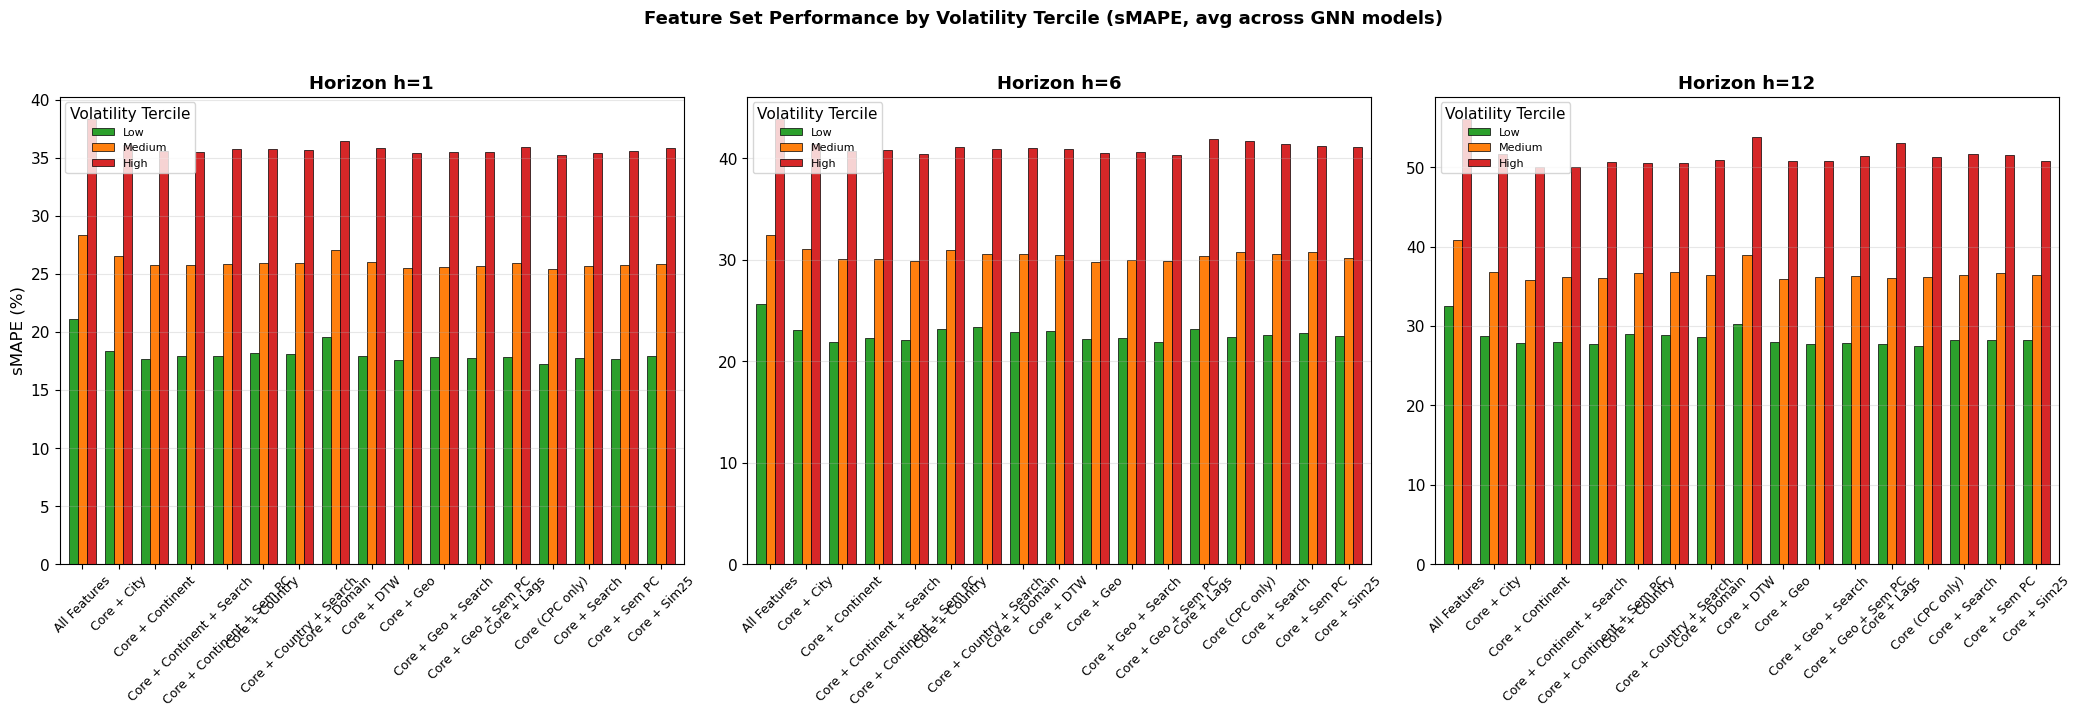

Saved: output/featureset_tercile_bars.pdf


In [38]:
# =============================================================================
# VIZ 1: Feature Set Performance by Tercile — grouped bars (avg across models)
# =============================================================================

abl_terc = abl_df[abl_df['seg_type'] == 'tercile']
horizons = sorted(abl_terc['horizon'].unique())
terc_colors = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}

fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 7), sharey=False)
if len(horizons) == 1:
    axes = [axes]

for i, h in enumerate(horizons):
    ax = axes[i]
    sub = abl_terc[abl_terc['horizon'] == h]
    pivot = sub.pivot_table(index='feature_set', columns='segment',
                            values='sMAPE', aggfunc='mean')
    cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
    pivot = pivot[cols]
    pivot.index = pivot.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))

    pivot.plot(kind='bar', ax=ax, color=[terc_colors[c] for c in cols],
               edgecolor='black', linewidth=0.5, width=0.75)
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('sMAPE (%)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.legend(title='Volatility Tercile', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

figure_path = output_path('featureset_tercile_bars.pdf')
plt.suptitle('Feature Set Performance by Volatility Tercile (sMAPE, avg across GNN models)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

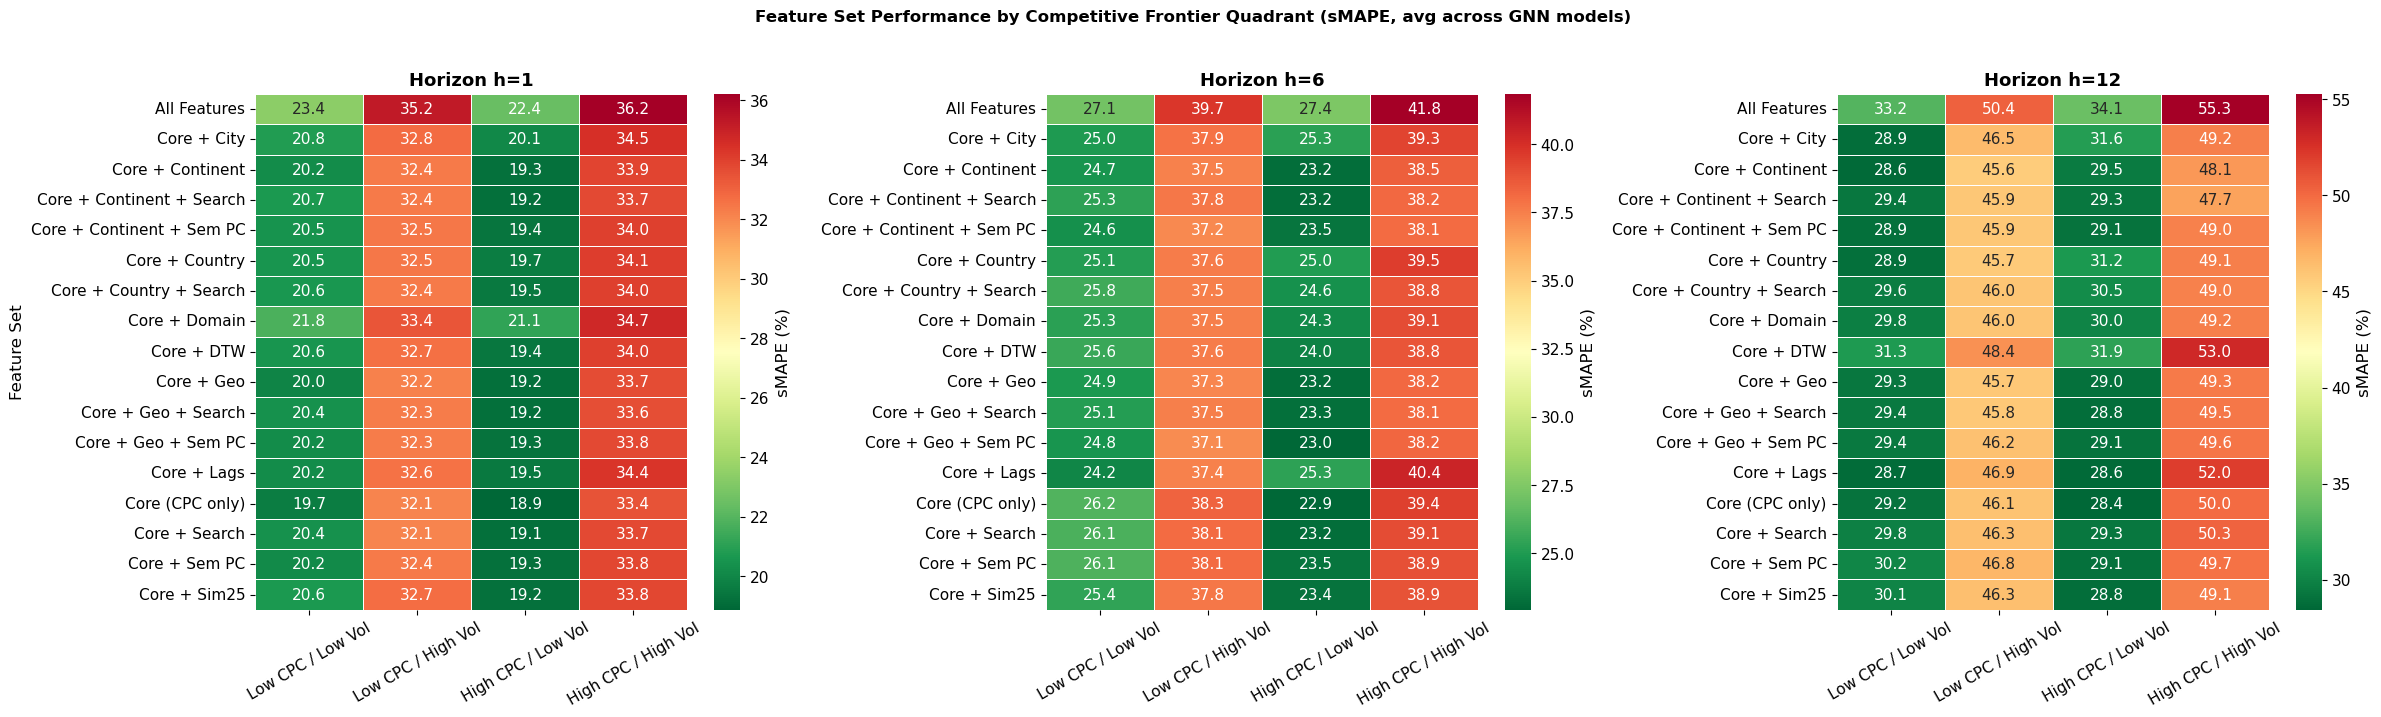

Saved: output/featureset_quadrant_heatmaps.pdf


In [39]:
# =============================================================================
# VIZ 2: Feature Set x Segment Heatmap (sMAPE, avg across models)
# =============================================================================

fig, axes = plt.subplots(1, len(horizons), figsize=(8 * len(horizons), 7))
if len(horizons) == 1:
    axes = [axes]

abl_quad = abl_df[abl_df['seg_type'] == 'quadrant']
for i, h in enumerate(horizons):
    ax = axes[i]
    sub = abl_quad[abl_quad['horizon'] == h]
    pivot = sub.pivot_table(index='feature_set', columns='segment',
                            values='sMAPE', aggfunc='mean')
    cols = [c for c in quadrant_order if c in pivot.columns]
    pivot = pivot[cols]
    pivot.index = pivot.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))

    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'sMAPE (%)'})
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_ylabel('' if i > 0 else 'Feature Set')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

figure_path = output_path('featureset_quadrant_heatmaps.pdf')
plt.suptitle('Feature Set Performance by Competitive Frontier Quadrant (sMAPE, avg across GNN models)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

In [40]:
# =============================================================================
# TABLE 2: Feature Set Impact — Δ sMAPE relative to Core (CPC only) baseline
# =============================================================================
# For each feature set, compute the change in sMAPE vs core_only.
# Negative = improvement.  Shows which features help most, and whether
# the benefit is concentrated in high-volatility segments.
# =============================================================================

abl_terc = abl_df[abl_df['seg_type'] == 'tercile']
abl_overall = abl_df[abl_df['seg_type'] == 'overall']

print("=" * 90)
print("TABLE 2: Feature Set Impact — Δ sMAPE vs Core-Only Baseline (avg across models)")
print("=" * 90)

for h in sorted(abl_terc['horizon'].unique()):
    print(f"\n{'─'*90}")
    print(f"  Horizon h={h}")
    print(f"{'─'*90}")

    # Tercile pivot for this horizon
    sub_t = abl_terc[abl_terc['horizon'] == h]
    pivot = sub_t.pivot_table(
        index='feature_set', columns='segment',
        values='sMAPE', aggfunc='mean'
    )
    cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
    pivot = pivot[cols]

    # Overall
    sub_o = abl_overall[abl_overall['horizon'] == h]
    ov = sub_o.groupby('feature_set')['sMAPE'].mean()
    pivot['Overall'] = ov

    # Compute delta from core_only
    if 'core_only' in pivot.index:
        baseline = pivot.loc['core_only']
        delta = pivot.subtract(baseline)
        delta = delta.drop('core_only', errors='ignore')
        delta.index = delta.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))

        # Sort by Overall improvement (most negative = most improved)
        delta = delta.sort_values('Overall')
        print(delta.round(2).to_string())
        print(f"\n  (Negative = improvement vs Core-Only)")
    else:
        print("  core_only baseline not available for this horizon")

TABLE 2: Feature Set Impact — Δ sMAPE vs Core-Only Baseline (avg across models)

──────────────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
──────────────────────────────────────────────────────────────────────────────────────────
segment                     Low  Medium  High  Overall
feature_set                                           
Core + Geo                 0.38    0.13  0.19     0.23
Core + Search              0.51    0.25  0.14     0.30
Core + Geo + Search        0.62    0.22  0.25     0.36
Core + Geo + Sem PC        0.53    0.30  0.28     0.37
Core + Sem PC              0.45    0.37  0.32     0.38
Core + Continent           0.47    0.37  0.37     0.40
Core + Continent + Search  0.71    0.35  0.29     0.45
Core + Continent + Sem PC  0.70    0.48  0.47     0.55
Core + Sim25               0.69    0.44  0.59     0.57
Core + Country + Search    0.85    0.50  0.40     0.58
Core + DTW                 0.73    0.60  0.60     0.64
Core + L

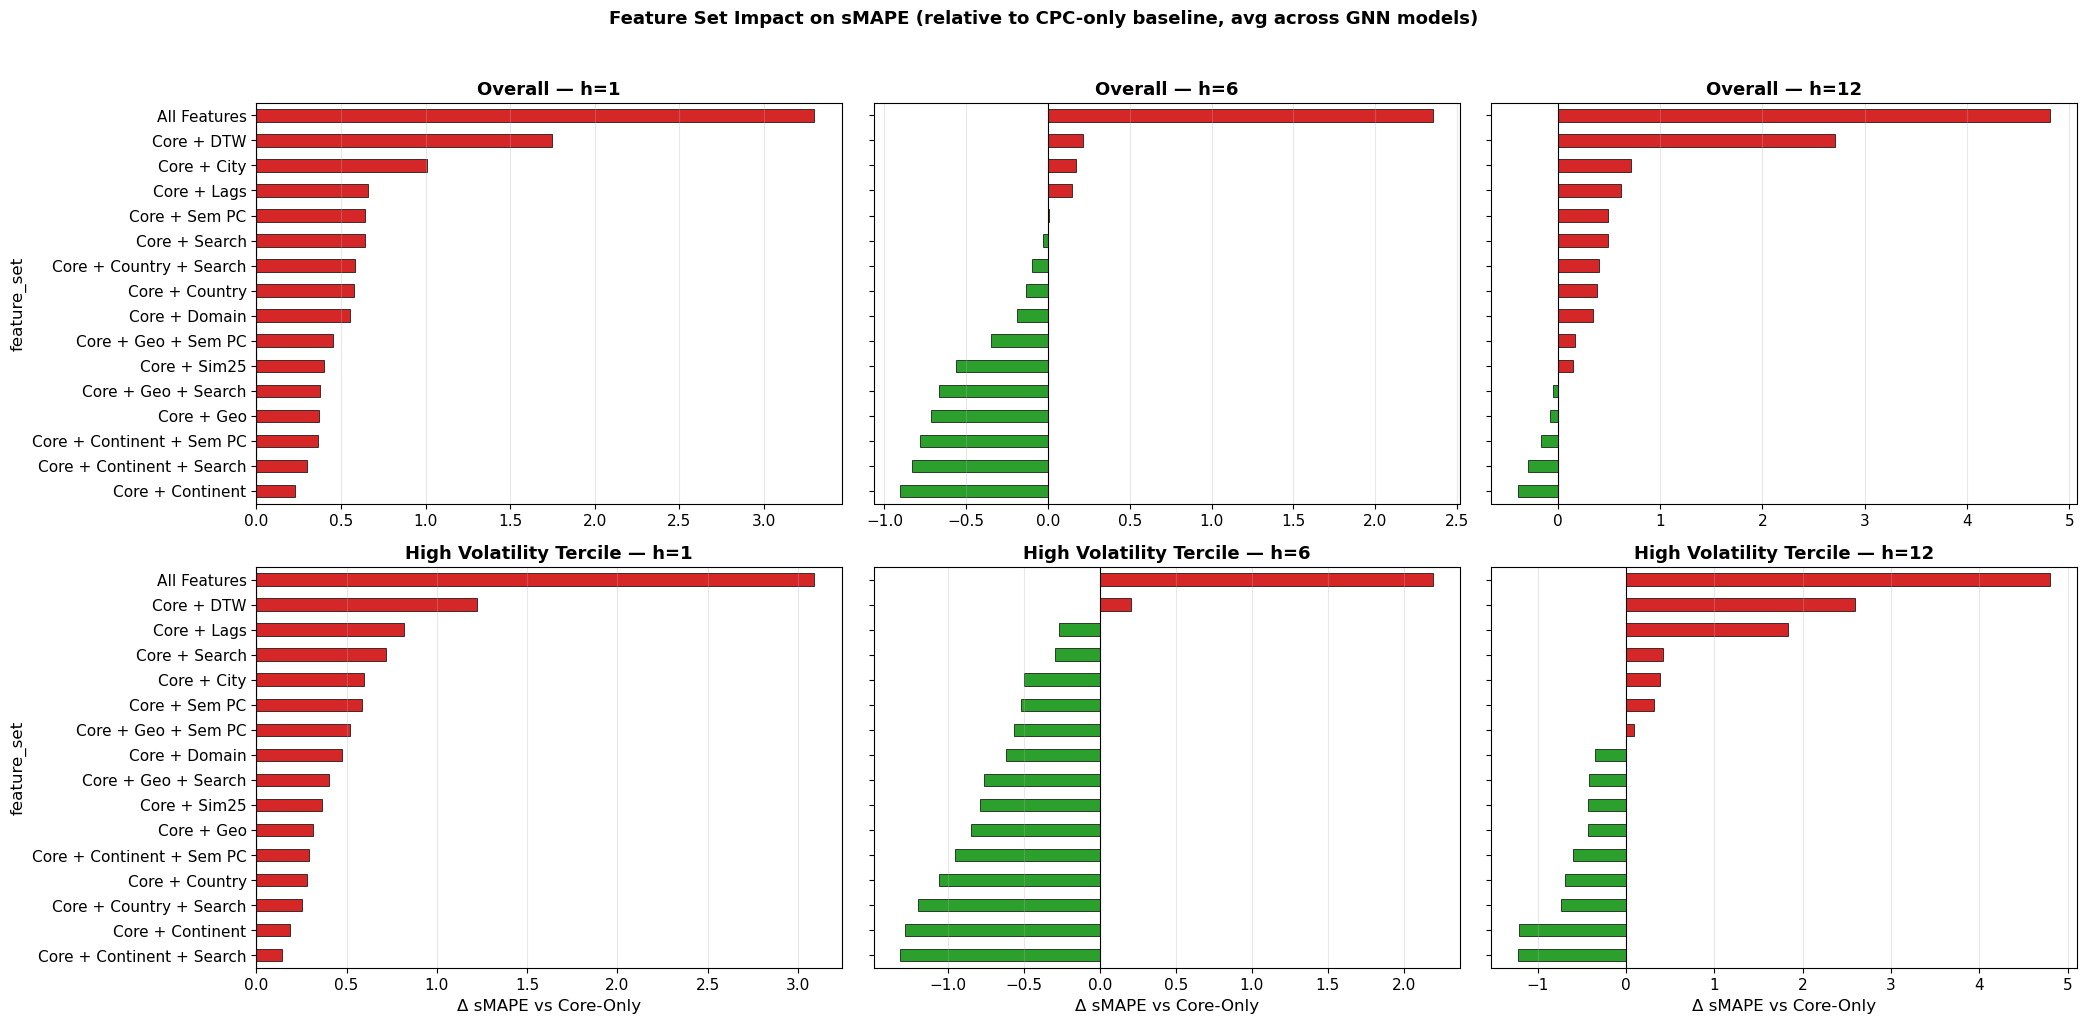

Saved: output/featureset_impact_bars.pdf


In [41]:
# =============================================================================
# VIZ 3: Feature Set Impact — Δ sMAPE bars (Overall + High Tercile)
# =============================================================================
# Horizontal bars showing improvement / degradation vs core_only.
# Bars to the left (green) = improvement.  Two rows of subplots:
#   Top: Overall impact
#   Bottom: High-volatility tercile impact (the "hardest" segment)
# =============================================================================

abl_terc = abl_df[abl_df['seg_type'] == 'tercile']
abl_overall = abl_df[abl_df['seg_type'] == 'overall']

fig, axes = plt.subplots(2, len(horizons), figsize=(7 * len(horizons), 10), sharey='row')
if len(horizons) == 1:
    axes = axes.reshape(2, 1)

for seg_row, (seg_name, seg_label) in enumerate([('overall', 'Overall'),
                                                   ('tercile_high', 'High Volatility Tercile')]):
    for i, h in enumerate(horizons):
        ax = axes[seg_row, i]

        # Get pivot for this segment
        if seg_name == 'overall':
            sub = abl_overall[abl_overall['horizon'] == h]
            pv = sub.groupby('feature_set')['sMAPE'].mean()
        else:
            sub = abl_terc[(abl_terc['horizon'] == h) & (abl_terc['segment'] == 'High')]
            pv = sub.groupby('feature_set')['sMAPE'].mean()

        if 'core_only' not in pv.index:
            ax.set_title(f'h={h} (no baseline)')
            continue

        baseline = pv['core_only']
        delta = pv.drop('core_only') - baseline
        delta.index = delta.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))
        delta = delta.sort_values()

        colors = ['#2ca02c' if d < 0 else '#d62728' for d in delta]
        delta.plot(kind='barh', ax=ax, color=colors,
                   edgecolor='black', linewidth=0.5)
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('Δ sMAPE vs Core-Only' if seg_row == 1 else '')
        ax.set_title(f'{seg_label} — h={h}', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

figure_path = output_path('featureset_impact_bars.pdf')
plt.suptitle('Feature Set Impact on sMAPE (relative to CPC-only baseline, avg across GNN models)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

In [42]:
# =============================================================================
# TABLE 3: Model × Feature Set Interaction — per-model breakdown
# =============================================================================
# SECONDARY axis: which GNN architectures benefit most from which features?
# Shows sMAPE per (model, feature_set) for the overall segment.
# =============================================================================

abl_overall = abl_df[abl_df['seg_type'] == 'overall']

print("=" * 90)
print("TABLE 3: Model × Feature Set Interaction (Overall sMAPE)")
print("  Rows = Feature Set, Columns = Model Architecture")
print("=" * 90)

for h in sorted(abl_overall['horizon'].unique()):
    print(f"\n{'─'*90}")
    print(f"  Horizon h={h}")
    print(f"{'─'*90}")
    sub = abl_overall[abl_overall['horizon'] == h]

    pivot = sub.pivot_table(
        index='feature_set', columns='model',
        values='sMAPE', aggfunc='mean'
    )
    # Add model-average column
    pivot['Avg'] = pivot.mean(axis=1)
    pivot.index = pivot.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))
    pivot = pivot.sort_values('Avg')
    print(pivot.round(2).to_string())

TABLE 3: Model × Feature Set Interaction (Overall sMAPE)
  Rows = Feature Set, Columns = Model Architecture

──────────────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
──────────────────────────────────────────────────────────────────────────────────────────
model                      A3TGCN  AGCRN  DCRNN  GConvLSTM  GraphWaveNet  MTGNN  STConv  STGCN    Avg
feature_set                                                                                          
Core (CPC only)               NaN    NaN  26.09        NaN         25.83    NaN     NaN    NaN  25.96
Core + Geo                    NaN  26.77  25.88      26.34         25.77    NaN     NaN    NaN  26.19
Core + Search                 NaN  26.81    NaN        NaN         25.72    NaN     NaN    NaN  26.26
Core + Geo + Search           NaN  26.83  26.01      26.73         25.72    NaN     NaN    NaN  26.32
Core + Geo + Sem PC           NaN  26.95  25.83      26.56         25.99    NaN    

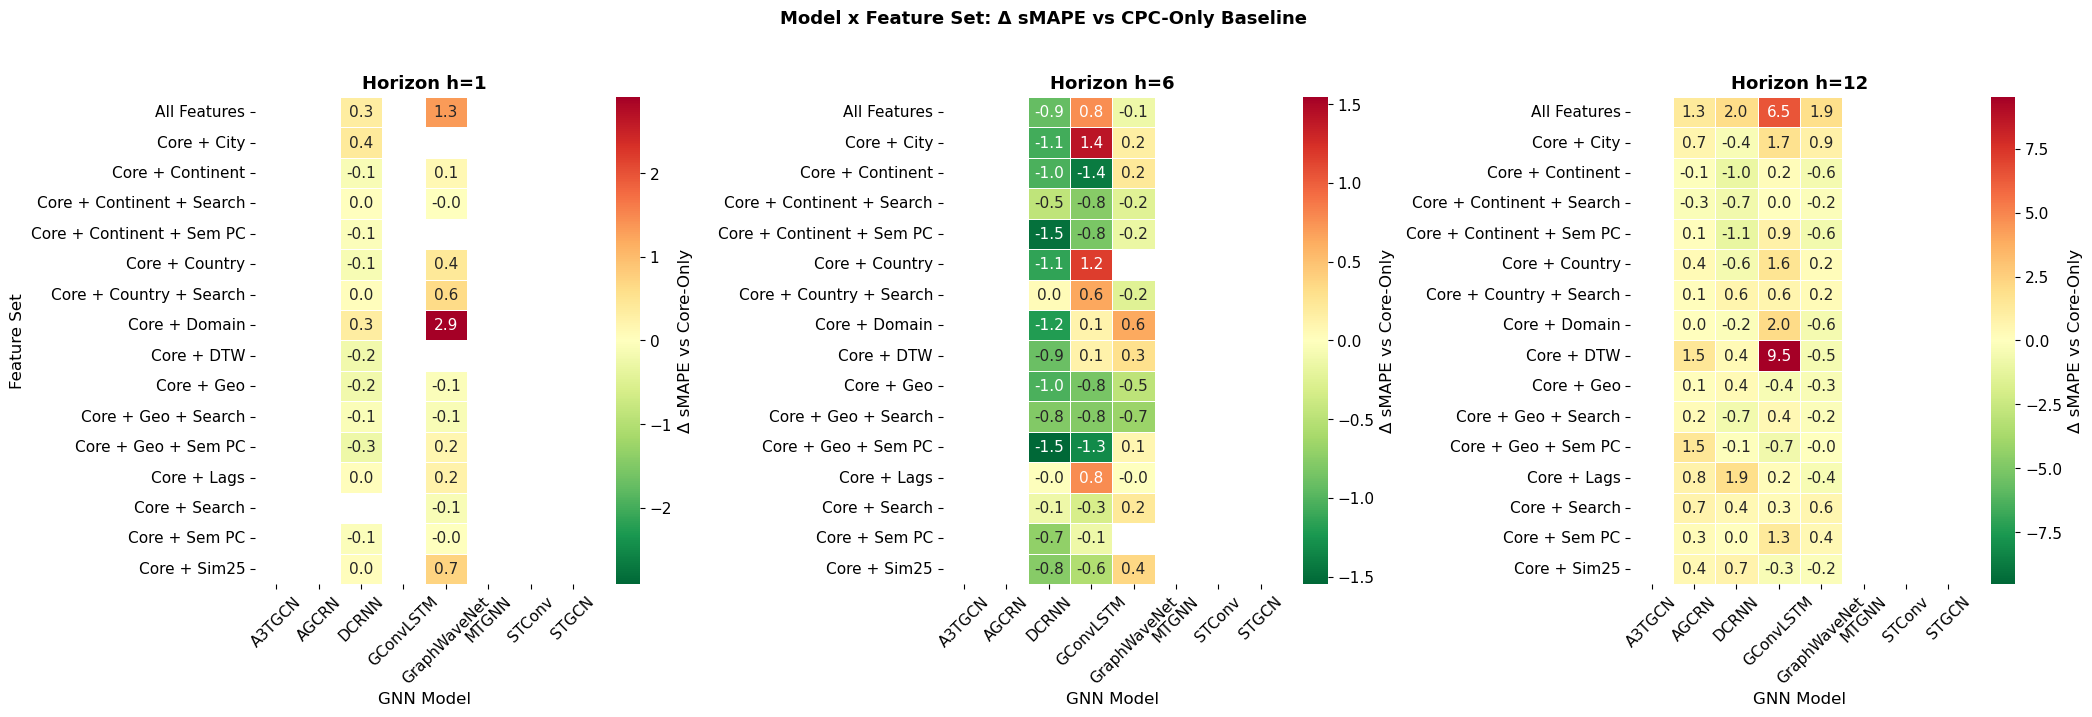

Saved: output/model_featureset_heatmap.pdf


In [43]:
# =============================================================================
# VIZ 4: Model x Feature Set Heatmap (sMAPE improvement vs Core-Only)
# =============================================================================
# Heatmap: y = feature set, x = model.  Color = Δ sMAPE vs core_only.
# Green = improvement, Red = degradation.
# =============================================================================

abl_overall = abl_df[abl_df['seg_type'] == 'overall']

fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 7))
if len(horizons) == 1:
    axes = [axes]

for i, h in enumerate(horizons):
    ax = axes[i]
    sub = abl_overall[abl_overall['horizon'] == h]

    pivot = sub.pivot_table(
        index='feature_set', columns='model',
        values='sMAPE', aggfunc='mean'
    )

    # Compute delta from core_only
    if 'core_only' in pivot.index:
        baseline = pivot.loc['core_only']
        delta = pivot.subtract(baseline).drop('core_only', errors='ignore')
        delta.index = delta.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))

        # Diverging colormap centered at 0
        vmax = max(abs(delta.min().min()), abs(delta.max().max()))
        sns.heatmap(delta, annot=True, fmt='.1f', cmap='RdYlGn_r',
                    center=0, vmin=-vmax, vmax=vmax,
                    ax=ax, linewidths=0.5,
                    cbar_kws={'label': 'Δ sMAPE vs Core-Only'})
        ax.set_title(f'Horizon h={h}', fontweight='bold')
        ax.set_ylabel('' if i > 0 else 'Feature Set')
        ax.set_xlabel('GNN Model')
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)
    else:
        ax.set_title(f'h={h} (no baseline)')

figure_path = output_path('model_featureset_heatmap.pdf')
plt.suptitle('Model x Feature Set: Δ sMAPE vs CPC-Only Baseline',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

# Benchmark Comparison

Compare GNN feature-set experiments against external baselines (ML, NN, SARIMAX).
Benchmarks are treated as "already optimized" — we pick the best exog_mode per
model and horizon, then compare directly against GNN feature sets.


In [44]:
# =============================================================================
# Load benchmark CSVs — treat as "already optimized" baselines
# =============================================================================
# For each benchmark model, pick the best exog_mode (lowest overall sMAPE)
# per horizon.  This gives us a single performance number per benchmark model
# to compare against GNN feature-set experiments.
# =============================================================================

ML_METRICS_PATH = "../3_Benchmarks/results/all_models_per_keyword_metrics.csv"
SARIMAX_METRICS_PATH = "../3_Benchmarks/results/sarimax_per_keyword_metrics_full.csv"

dfs = []
for path, label in [(ML_METRICS_PATH, 'ML/NN'), (SARIMAX_METRICS_PATH, 'SARIMAX')]:
    try:
        tmp = pd.read_csv(path)
        dfs.append(tmp)
        print(f"Loaded {label}: {len(tmp)} rows, models={sorted(tmp['model_id'].unique())}")
    except FileNotFoundError:
        print(f"WARNING: {path} not found, skipping.")

df_benchmarks = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

if not df_benchmarks.empty:
    # Merge with keyword segments
    stats_sub = keyword_stats.reset_index()[['keyword', 'vol_tercile', 'quadrant', 'node_idx']]
    df_bm = df_benchmarks.merge(stats_sub, on='keyword', how='inner')
    print(f"\nAfter merge: {len(df_bm)} rows ({df_bm['keyword'].nunique()} keywords)")

    # --- For each (model_id, horizon), find the best exog_mode (lowest mean sMAPE) ---
    best_exog = (
        df_bm.groupby(['model_id', 'horizon', 'exog_mode'])['smape']
        .mean()
        .reset_index()
        .sort_values('smape')
        .drop_duplicates(subset=['model_id', 'horizon'], keep='first')
    )
    print(f"\nBest exog_mode per (model, horizon):")
    for _, row in best_exog.iterrows():
        print(f"  {row['model_id']:>20s}  h={int(row['horizon'])}  -> {row['exog_mode']} (sMAPE={row['smape']:.1f}%)")

    # Keep only the best exog_mode rows for each (model_id, horizon)
    keep_keys = set(zip(best_exog['model_id'], best_exog['horizon'], best_exog['exog_mode']))
    df_bm_best = df_bm[df_bm.apply(
        lambda r: (r['model_id'], r['horizon'], r['exog_mode']) in keep_keys, axis=1
    )].copy()

    # --- Aggregate to segment-level metrics ---
    bench_rows = []
    for (model_id, horizon), grp in df_bm_best.groupby(['model_id', 'horizon']):
        row_base = dict(model=model_id, horizon=int(horizon))

        # Overall
        bench_rows.append({
            **row_base, 'seg_type': 'overall', 'segment': 'All',
            'sMAPE': grp['smape'].mean(), 'RMSE': grp['rmse'].mean(),
            'n_keywords': grp['keyword'].nunique(),
        })

        # Tercile
        for terc in ['Low', 'Medium', 'High']:
            sub = grp[grp['vol_tercile'] == terc]
            if len(sub):
                bench_rows.append({
                    **row_base, 'seg_type': 'tercile', 'segment': terc,
                    'sMAPE': sub['smape'].mean(), 'RMSE': sub['rmse'].mean(),
                    'n_keywords': sub['keyword'].nunique(),
                })

        # Quadrant
        for quad in quadrant_order:
            sub = grp[grp['quadrant'] == quad]
            if len(sub):
                bench_rows.append({
                    **row_base, 'seg_type': 'quadrant', 'segment': quad,
                    'sMAPE': sub['smape'].mean(), 'RMSE': sub['rmse'].mean(),
                    'n_keywords': sub['keyword'].nunique(),
                })

    df_bench_seg = pd.DataFrame(bench_rows)
    df_bench_seg['source'] = 'Benchmark'
    print(f"\nBenchmark segment-level rows: {len(df_bench_seg)}")
else:
    df_bench_seg = pd.DataFrame()
    print("No benchmarks loaded.")

Loaded ML/NN: 114039 rows, models=['ml | LGBM', 'ml | RF', 'ml | XGB', 'nn | GRU', 'nn | LSTM', 'nn | MLP', 'stats | SARIMAX_kw']
Loaded SARIMAX: 16299 rows, models=['stats | SARIMAX_kw']

After merge: 130338 rows (1811 keywords)

Best exog_mode per (model, horizon):
              nn | MLP  h=1  -> exog_small (sMAPE=30.4%)
             ml | LGBM  h=1  -> exog_small (sMAPE=30.7%)
             nn | LSTM  h=1  -> exog_small (sMAPE=30.7%)
              ml | XGB  h=1  -> exog_small (sMAPE=30.7%)
              nn | GRU  h=1  -> exog_small (sMAPE=31.0%)
               ml | RF  h=1  -> exog_all (sMAPE=31.5%)
              nn | GRU  h=6  -> exog_small (sMAPE=36.4%)
             ml | LGBM  h=6  -> exog_small (sMAPE=36.6%)
             nn | LSTM  h=6  -> exog_small (sMAPE=36.6%)
              ml | XGB  h=6  -> exog_small (sMAPE=36.6%)
              nn | MLP  h=6  -> cpc_only (sMAPE=37.2%)
               ml | RF  h=6  -> exog_small (sMAPE=38.2%)
              nn | MLP  h=12  -> exog_small (sMAPE=4

In [45]:
# =============================================================================
# TABLE 4: GNN Feature Sets vs Benchmark Baselines — Tercile Comparison
# =============================================================================
# Compare GNN ablation experiments (averaged across models) against the best
# benchmark baselines.  GNN rows are labeled by feature set; benchmark rows
# by model name.
# =============================================================================

# Prepare GNN summary: average across models for each feature_set
abl_terc = abl_df[abl_df['seg_type'] == 'tercile']
abl_overall = abl_df[abl_df['seg_type'] == 'overall']

gnn_terc_summary = abl_terc.groupby(['feature_set', 'horizon', 'segment'])['sMAPE'].mean().reset_index()
gnn_terc_summary['source'] = 'GNN (avg)'
gnn_terc_summary['label'] = gnn_terc_summary['feature_set'].map(
    lambda x: f"GNN: {FEATURE_SET_LABELS.get(x, x)}"
)

gnn_overall_summary = abl_overall.groupby(['feature_set', 'horizon'])['sMAPE'].mean().reset_index()
gnn_overall_summary['source'] = 'GNN (avg)'

# Benchmark tercile
bench_terc = df_bench_seg[df_bench_seg['seg_type'] == 'tercile'].copy() if len(df_bench_seg) else pd.DataFrame()
bench_overall = df_bench_seg[df_bench_seg['seg_type'] == 'overall'].copy() if len(df_bench_seg) else pd.DataFrame()

print("=" * 90)
print("TABLE 4: GNN Feature Sets vs Benchmark Baselines — Tercile (sMAPE)")
print("  GNN rows = avg across models | Benchmark rows = best exog_mode per model")
print("=" * 90)

for h in sorted(abl_terc['horizon'].unique()):
    print(f"\n{'─'*90}")
    print(f"  Horizon h={h}")
    print(f"{'─'*90}")

    # GNN part
    sub_g = gnn_terc_summary[gnn_terc_summary['horizon'] == h]
    pv_g = sub_g.pivot_table(index='label', columns='segment', values='sMAPE', aggfunc='mean')

    sub_go = gnn_overall_summary[gnn_overall_summary['horizon'] == h]
    ov_g = sub_go.set_index('feature_set')['sMAPE']
    ov_g.index = ov_g.index.map(lambda x: f"GNN: {FEATURE_SET_LABELS.get(x, x)}")
    pv_g['Overall'] = ov_g

    # Benchmark part
    if len(bench_terc):
        sub_b = bench_terc[bench_terc['horizon'] == h]
        pv_b = sub_b.pivot_table(index='model', columns='segment', values='sMAPE', aggfunc='mean')
        pv_b.index = pv_b.index.map(lambda x: f"BM: {x}")

        sub_bo = bench_overall[bench_overall['horizon'] == h]
        ov_b = sub_bo.set_index('model')['sMAPE']
        ov_b.index = ov_b.index.map(lambda x: f"BM: {x}")
        pv_b['Overall'] = ov_b

        pivot = pd.concat([pv_g, pv_b])
    else:
        pivot = pv_g

    cols = [c for c in ['Low', 'Medium', 'High', 'Overall'] if c in pivot.columns]
    pivot = pivot[cols]
    if 'High' in pivot.columns and 'Low' in pivot.columns:
        pivot['High/Low'] = (pivot['High'] / pivot['Low']).round(2)
    pivot = pivot.sort_values('Overall', na_position='last')
    print(pivot.round(2).to_string())

TABLE 4: GNN Feature Sets vs Benchmark Baselines — Tercile (sMAPE)
  GNN rows = avg across models | Benchmark rows = best exog_mode per model

──────────────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
──────────────────────────────────────────────────────────────────────────────────────────
segment                           Low  Medium   High  Overall  High/Low
GNN: Core (CPC only)            17.22   25.41  35.25    25.96      2.05
GNN: Core + Geo                 17.60   25.53  35.44    26.19      2.01
GNN: Core + Search              17.74   25.66  35.39    26.26      2.00
GNN: Core + Geo + Search        17.84   25.63  35.50    26.32      1.99
GNN: Core + Geo + Sem PC        17.75   25.71  35.53    26.33      2.00
GNN: Core + Sem PC              17.67   25.77  35.57    26.34      2.01
GNN: Core + Continent           17.69   25.78  35.62    26.36      2.01
GNN: Core + Continent + Search  17.94   25.75  35.55    26.41      1.98
GNN: Core + C

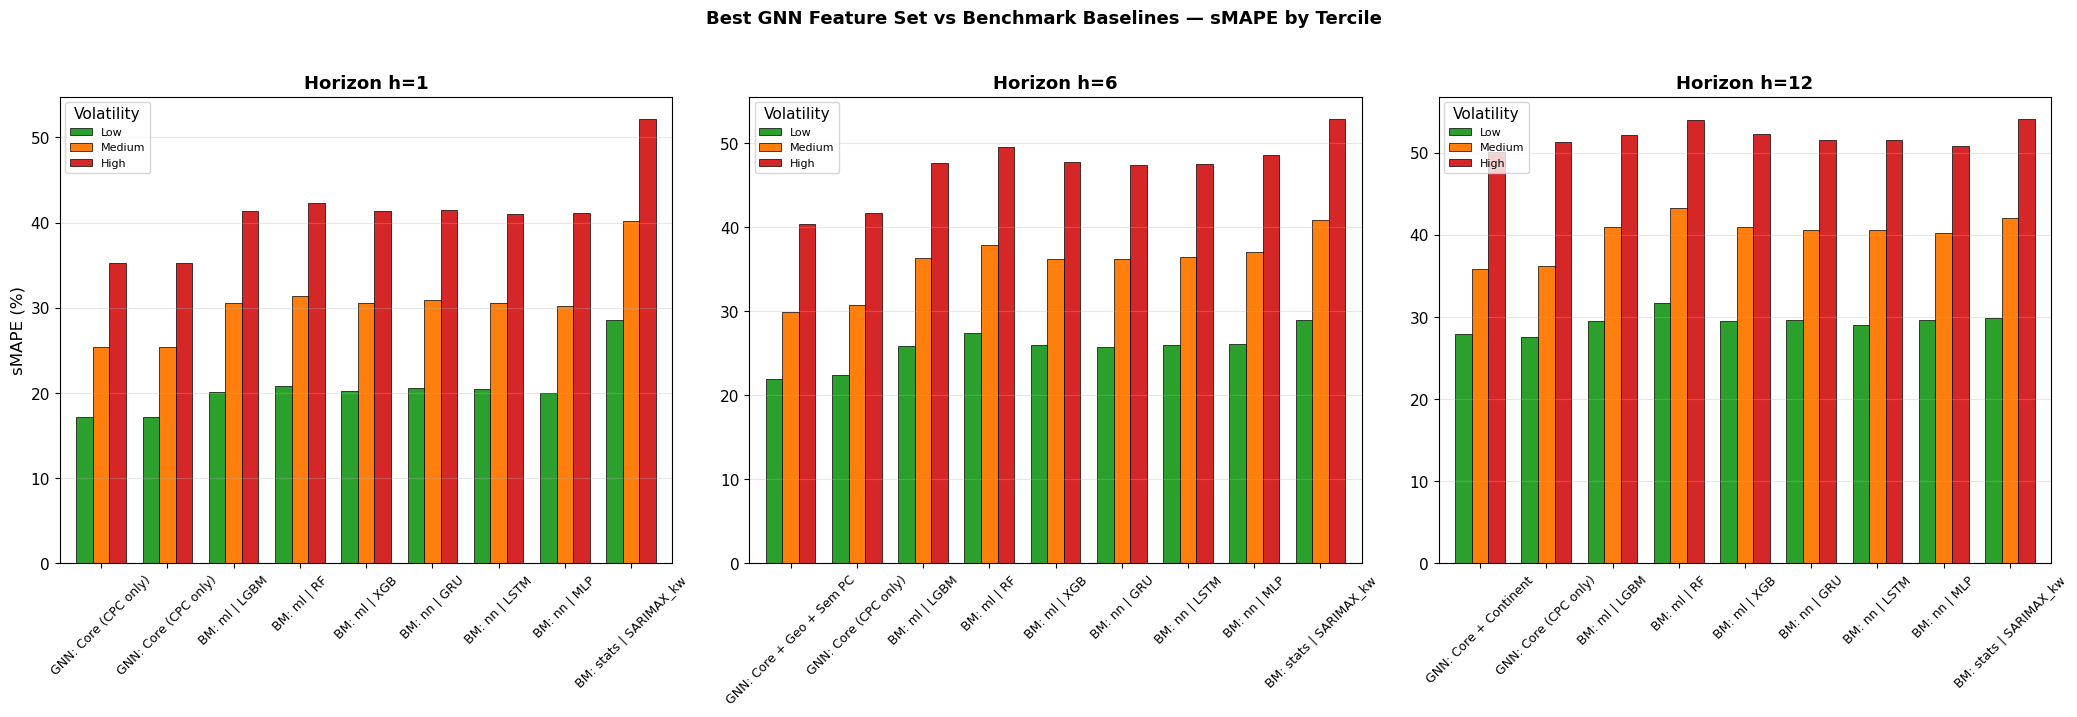

Saved: output/gnn_vs_benchmarks_tercile.pdf


In [46]:
# =============================================================================
# VIZ 5: GNN Best Feature Set vs Benchmarks — Tercile comparison
# =============================================================================
# Pick the best GNN feature set (by overall sMAPE, avg across models) and
# plot it alongside all benchmark baselines.
# =============================================================================

terc_colors = {'Low': '#2ca02c', 'Medium': '#ff7f0e', 'High': '#d62728'}

fig, axes = plt.subplots(1, len(horizons), figsize=(7 * len(horizons), 7), sharey=False)
if len(horizons) == 1:
    axes = [axes]

for i, h in enumerate(horizons):
    ax = axes[i]

    # Best GNN feature set for this horizon
    sub_o = abl_overall[abl_overall['horizon'] == h]
    fs_perf = sub_o.groupby('feature_set')['sMAPE'].mean()
    best_fs = fs_perf.idxmin()
    best_fs_label = FEATURE_SET_LABELS.get(best_fs, best_fs)

    # GNN tercile data for the best feature set
    sub_t = abl_terc[(abl_terc['horizon'] == h) & (abl_terc['feature_set'] == best_fs)]
    gnn_row = sub_t.groupby('segment')['sMAPE'].mean()
    gnn_row.name = f'GNN: {best_fs_label}'

    rows = [gnn_row]

    # Also include core_only for reference
    sub_core = abl_terc[(abl_terc['horizon'] == h) & (abl_terc['feature_set'] == 'core_only')]
    if len(sub_core):
        core_row = sub_core.groupby('segment')['sMAPE'].mean()
        core_row.name = 'GNN: Core (CPC only)'
        rows.append(core_row)

    # Benchmark rows
    if len(bench_terc):
        sub_b = bench_terc[bench_terc['horizon'] == h]
        for model in sorted(sub_b['model'].unique()):
            bm_row = sub_b[sub_b['model'] == model].groupby('segment')['sMAPE'].mean()
            bm_row.name = f'BM: {model}'
            rows.append(bm_row)

    pivot = pd.DataFrame(rows)
    cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
    pivot = pivot[cols]

    pivot.plot(kind='bar', ax=ax, color=[terc_colors[c] for c in cols],
               edgecolor='black', linewidth=0.5, width=0.75)
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('sMAPE (%)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.legend(title='Volatility', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

figure_path = output_path('gnn_vs_benchmarks_tercile.pdf')
plt.suptitle('Best GNN Feature Set vs Benchmark Baselines — sMAPE by Tercile',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

In [47]:
# =============================================================================
# TABLE 5: Geographic Granularity Deep-Dive
# =============================================================================
# Focused comparison of geographic feature granularity (city/country/continent)
# and their combinations with other features.  Uses core_only and core_geo as
# baselines for context.
# =============================================================================

geo_focus_sets = ['core_only', 'core_geo'] + COMBO_SETS + GEO_SETS
geo_df = abl_df[abl_df['feature_set'].isin(geo_focus_sets)]

if len(geo_df[geo_df['feature_set'].isin(COMBO_SETS + GEO_SETS)]) > 0:
    geo_terc = geo_df[geo_df['seg_type'] == 'tercile']
    geo_overall = geo_df[geo_df['seg_type'] == 'overall']

    print("=" * 90)
    print("TABLE 5: Geographic Feature Granularity Deep-Dive (sMAPE, avg across models)")
    print("=" * 90)

    for h in sorted(geo_terc['horizon'].unique()):
        print(f"\n{'─'*90}")
        print(f"  Horizon h={h}")
        print(f"{'─'*90}")

        sub_t = geo_terc[geo_terc['horizon'] == h]
        sub_o = geo_overall[geo_overall['horizon'] == h]

        pivot = sub_t.pivot_table(
            index='feature_set', columns='segment',
            values='sMAPE', aggfunc='mean'
        )
        cols = [c for c in ['Low', 'Medium', 'High'] if c in pivot.columns]
        pivot = pivot[cols]

        ov = sub_o.groupby('feature_set')['sMAPE'].mean()
        pivot['Overall'] = ov

        if 'core_only' in pivot.index and 'Overall' in pivot.columns:
            baseline_ov = pivot.loc['core_only', 'Overall']
            pivot['Δ vs Core'] = pivot['Overall'] - baseline_ov

        pivot.index = pivot.index.map(lambda x: FEATURE_SET_LABELS.get(x, x))
        pivot = pivot.sort_values('Overall', na_position='last')
        print(pivot.round(2).to_string())
else:
    print("No geographic/combination feature sets available in the data.")

TABLE 5: Geographic Feature Granularity Deep-Dive (sMAPE, avg across models)

──────────────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
──────────────────────────────────────────────────────────────────────────────────────────
segment                      Low  Medium   High  Overall  Δ vs Core
feature_set                                                        
Core (CPC only)            17.22   25.41  35.25    25.96       0.00
Core + Geo                 17.60   25.53  35.44    26.19       0.23
Core + Geo + Search        17.84   25.63  35.50    26.32       0.36
Core + Geo + Sem PC        17.75   25.71  35.53    26.33       0.37
Core + Continent           17.69   25.78  35.62    26.36       0.40
Core + Continent + Search  17.94   25.75  35.55    26.41       0.45
Core + Continent + Sem PC  17.92   25.89  35.72    26.51       0.55
Core + Country + Search    18.07   25.90  35.65    26.54       0.58
Core + Country             18.16   25.93  35.7

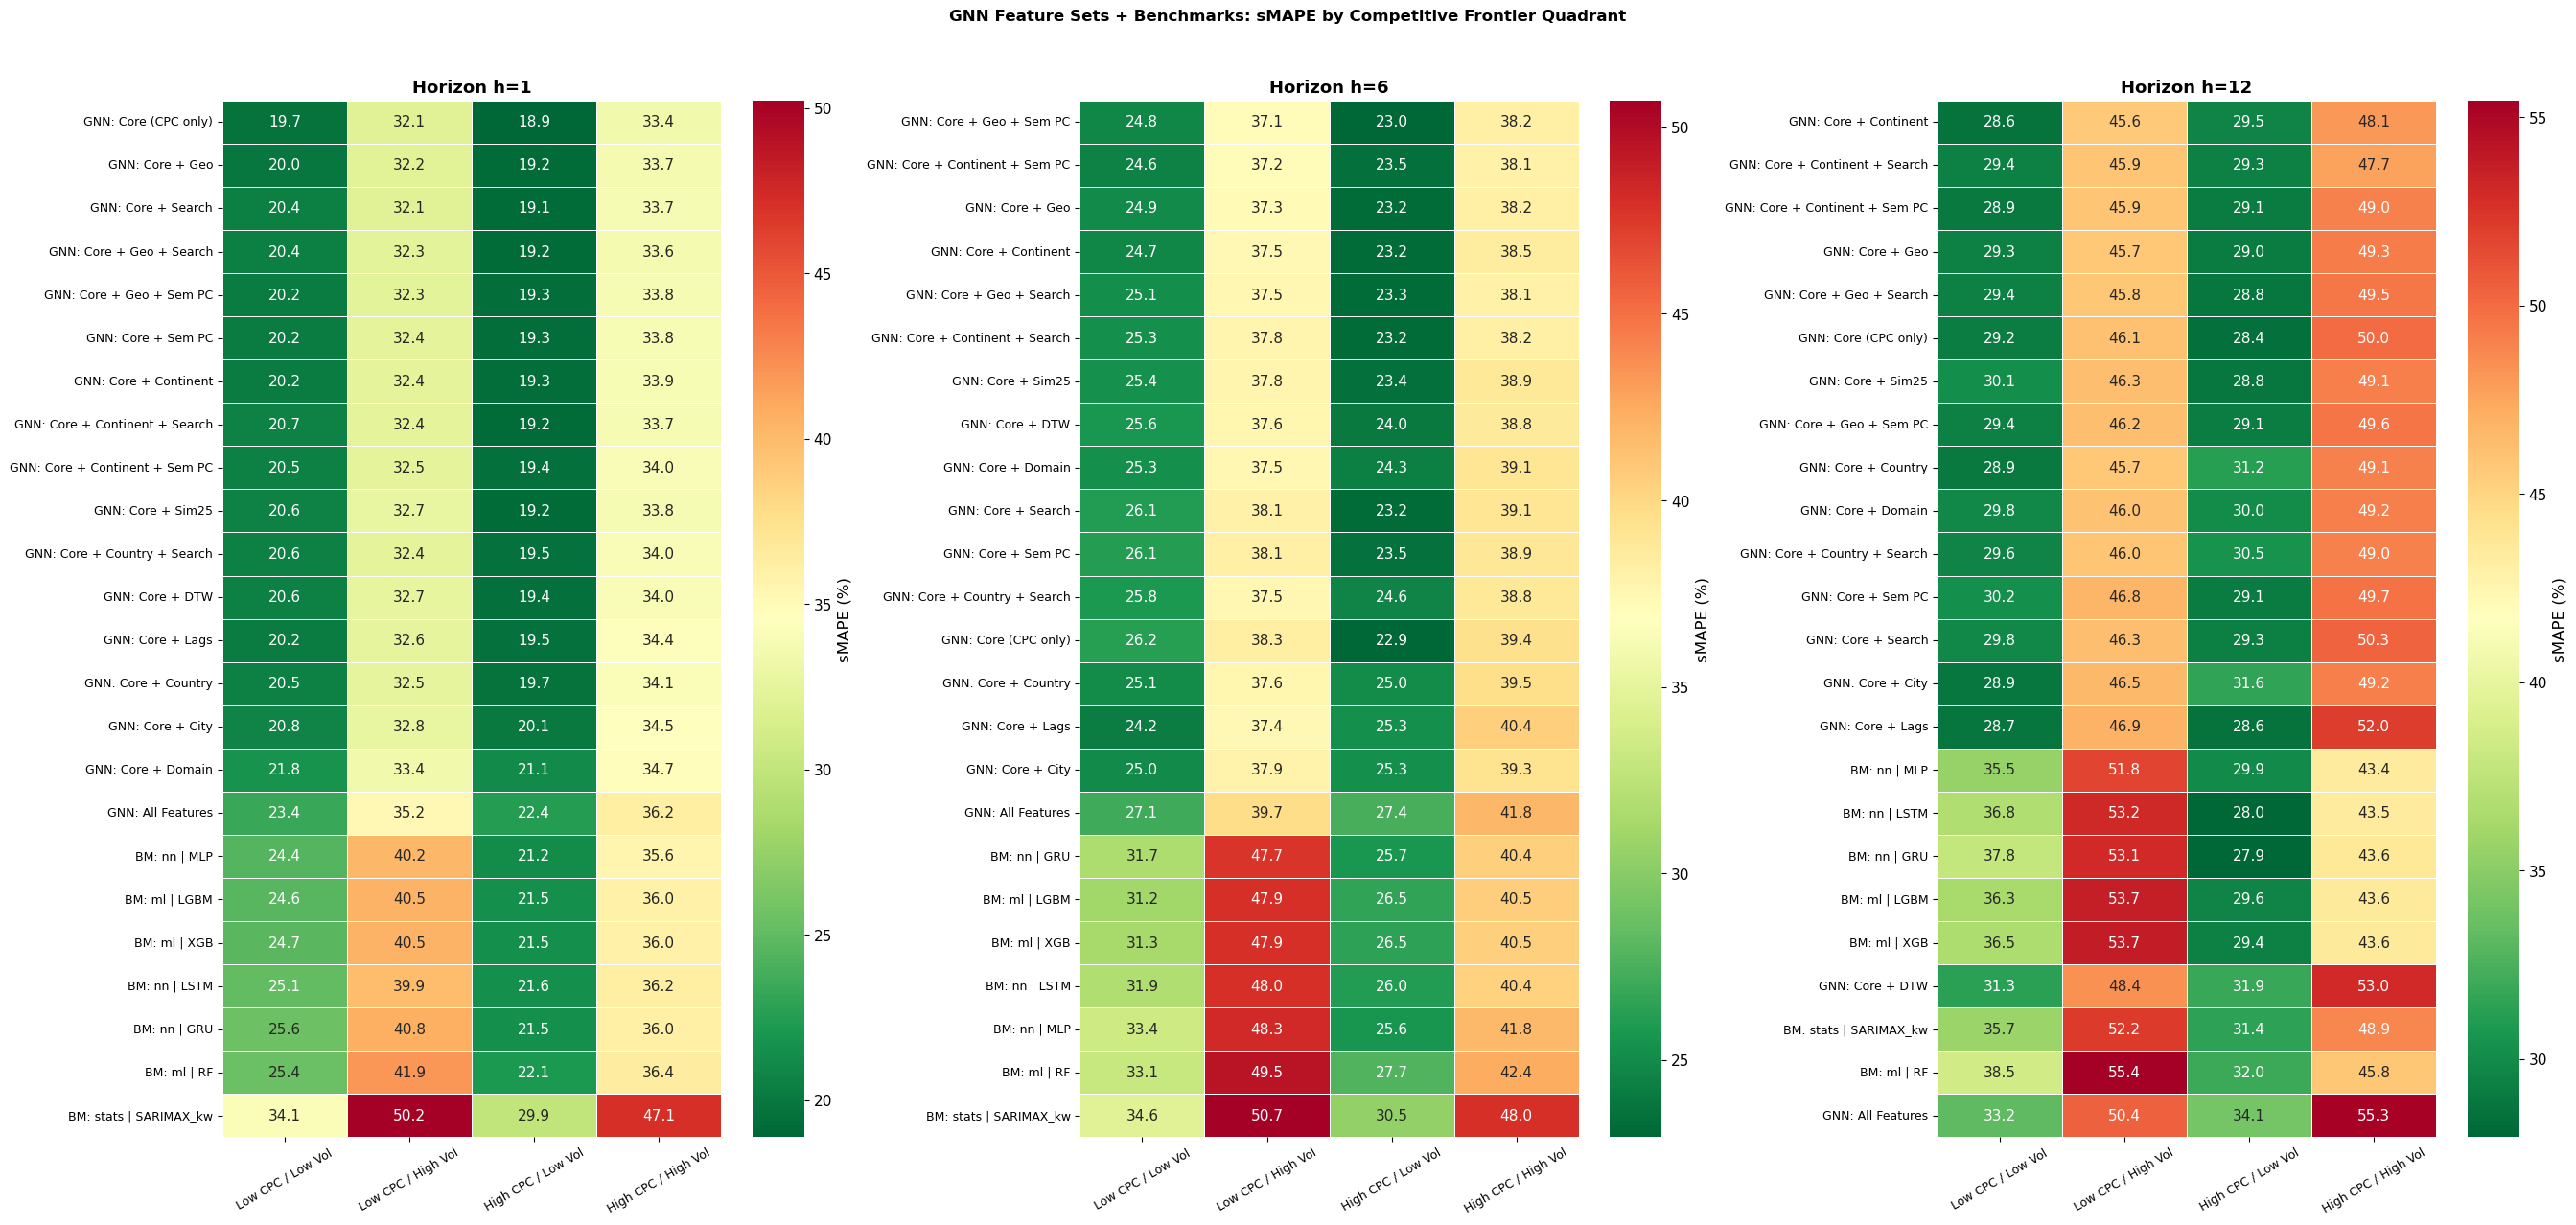

Saved: output/unified_featureset_quadrant_heatmaps.pdf


In [48]:
# =============================================================================
# VIZ 6: Combined Heatmap — GNN feature sets + Benchmarks by Quadrant
# =============================================================================
# Shows all GNN feature sets (averaged across models) and benchmark models
# in a single quadrant heatmap, sorted by overall sMAPE.
# =============================================================================

abl_quad = abl_df[abl_df['seg_type'] == 'quadrant']

fig, axes = plt.subplots(1, len(horizons),
                         figsize=(9 * len(horizons), max(9, len(set_order) * 0.5 + 4)))
if len(horizons) == 1:
    axes = [axes]

for i, h in enumerate(horizons):
    ax = axes[i]

    # GNN rows: feature_set (avg across models)
    sub_g = abl_quad[abl_quad['horizon'] == h]
    pv_g = sub_g.pivot_table(index='feature_set', columns='segment',
                              values='sMAPE', aggfunc='mean')
    pv_g.index = pv_g.index.map(lambda x: f"GNN: {FEATURE_SET_LABELS.get(x, x)}")

    # Benchmark rows
    if len(df_bench_seg):
        sub_b = df_bench_seg[(df_bench_seg['seg_type'] == 'quadrant') &
                              (df_bench_seg['horizon'] == h)]
        pv_b = sub_b.pivot_table(index='model', columns='segment',
                                  values='sMAPE', aggfunc='mean')
        pv_b.index = pv_b.index.map(lambda x: f"BM: {x}")
        pivot = pd.concat([pv_g, pv_b])
    else:
        pivot = pv_g

    cols = [c for c in quadrant_order if c in pivot.columns]
    pivot = pivot[cols]
    pivot['avg'] = pivot.mean(axis=1)
    pivot = pivot.sort_values('avg').drop('avg', axis=1)

    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'sMAPE (%)'})
    ax.set_title(f'Horizon h={h}', fontweight='bold')
    ax.set_ylabel('' if i > 0 else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

figure_path = output_path('unified_featureset_quadrant_heatmaps.pdf')
plt.suptitle('GNN Feature Sets + Benchmarks: sMAPE by Competitive Frontier Quadrant',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

In [49]:
# =============================================================================
# TABLE 6: Best Feature Set per GNN Model — per segment
# =============================================================================
# For each GNN model, which feature set gives the lowest sMAPE overall and
# in the High-volatility tercile?
# =============================================================================

abl_overall = abl_df[abl_df['seg_type'] == 'overall']
abl_terc = abl_df[abl_df['seg_type'] == 'tercile']

print("=" * 90)
print("TABLE 6: Best Feature Set per GNN Model & Segment")
print("=" * 90)

for h in sorted(abl_overall['horizon'].unique()):
    print(f"\n{'─'*90}")
    print(f"  Horizon h={h}")
    print(f"{'─'*90}")

    rows = []
    for model in sorted(abl_overall['model'].unique()):
        # Overall best
        sub_o = abl_overall[(abl_overall['horizon'] == h) & (abl_overall['model'] == model)]
        if len(sub_o) == 0:
            continue
        best_o = sub_o.loc[sub_o['sMAPE'].idxmin()]

        # High tercile best
        sub_h = abl_terc[(abl_terc['horizon'] == h) &
                         (abl_terc['model'] == model) &
                         (abl_terc['segment'] == 'High')]
        best_h_fs = '-'
        best_h_val = np.nan
        if len(sub_h):
            best_h = sub_h.loc[sub_h['sMAPE'].idxmin()]
            best_h_fs = FEATURE_SET_LABELS.get(best_h['feature_set'], best_h['feature_set'])
            best_h_val = best_h['sMAPE']

        rows.append({
            'Model': model,
            'Best Overall FS': FEATURE_SET_LABELS.get(best_o['feature_set'], best_o['feature_set']),
            'Overall sMAPE': best_o['sMAPE'],
            'Best High-Vol FS': best_h_fs,
            'High-Vol sMAPE': best_h_val,
        })

    if rows:
        print(pd.DataFrame(rows).set_index('Model').round(2).to_string())

TABLE 6: Best Feature Set per GNN Model & Segment

──────────────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
──────────────────────────────────────────────────────────────────────────────────────────
                  Best Overall FS  Overall sMAPE     Best High-Vol FS  High-Vol sMAPE
Model                                                                                
A3TGCN               All Features          38.50         All Features           46.72
AGCRN                  Core + Geo          26.77  Core + Geo + Search           35.95
DCRNN         Core + Geo + Sem PC          25.83  Core + Geo + Sem PC           35.07
GConvLSTM              Core + Geo          26.34           Core + Geo           35.65
GraphWaveNet        Core + Search          25.72        Core + Search           34.75
MTGNN                All Features          30.43         All Features           40.21
STConv               All Features          29.73         All Feat

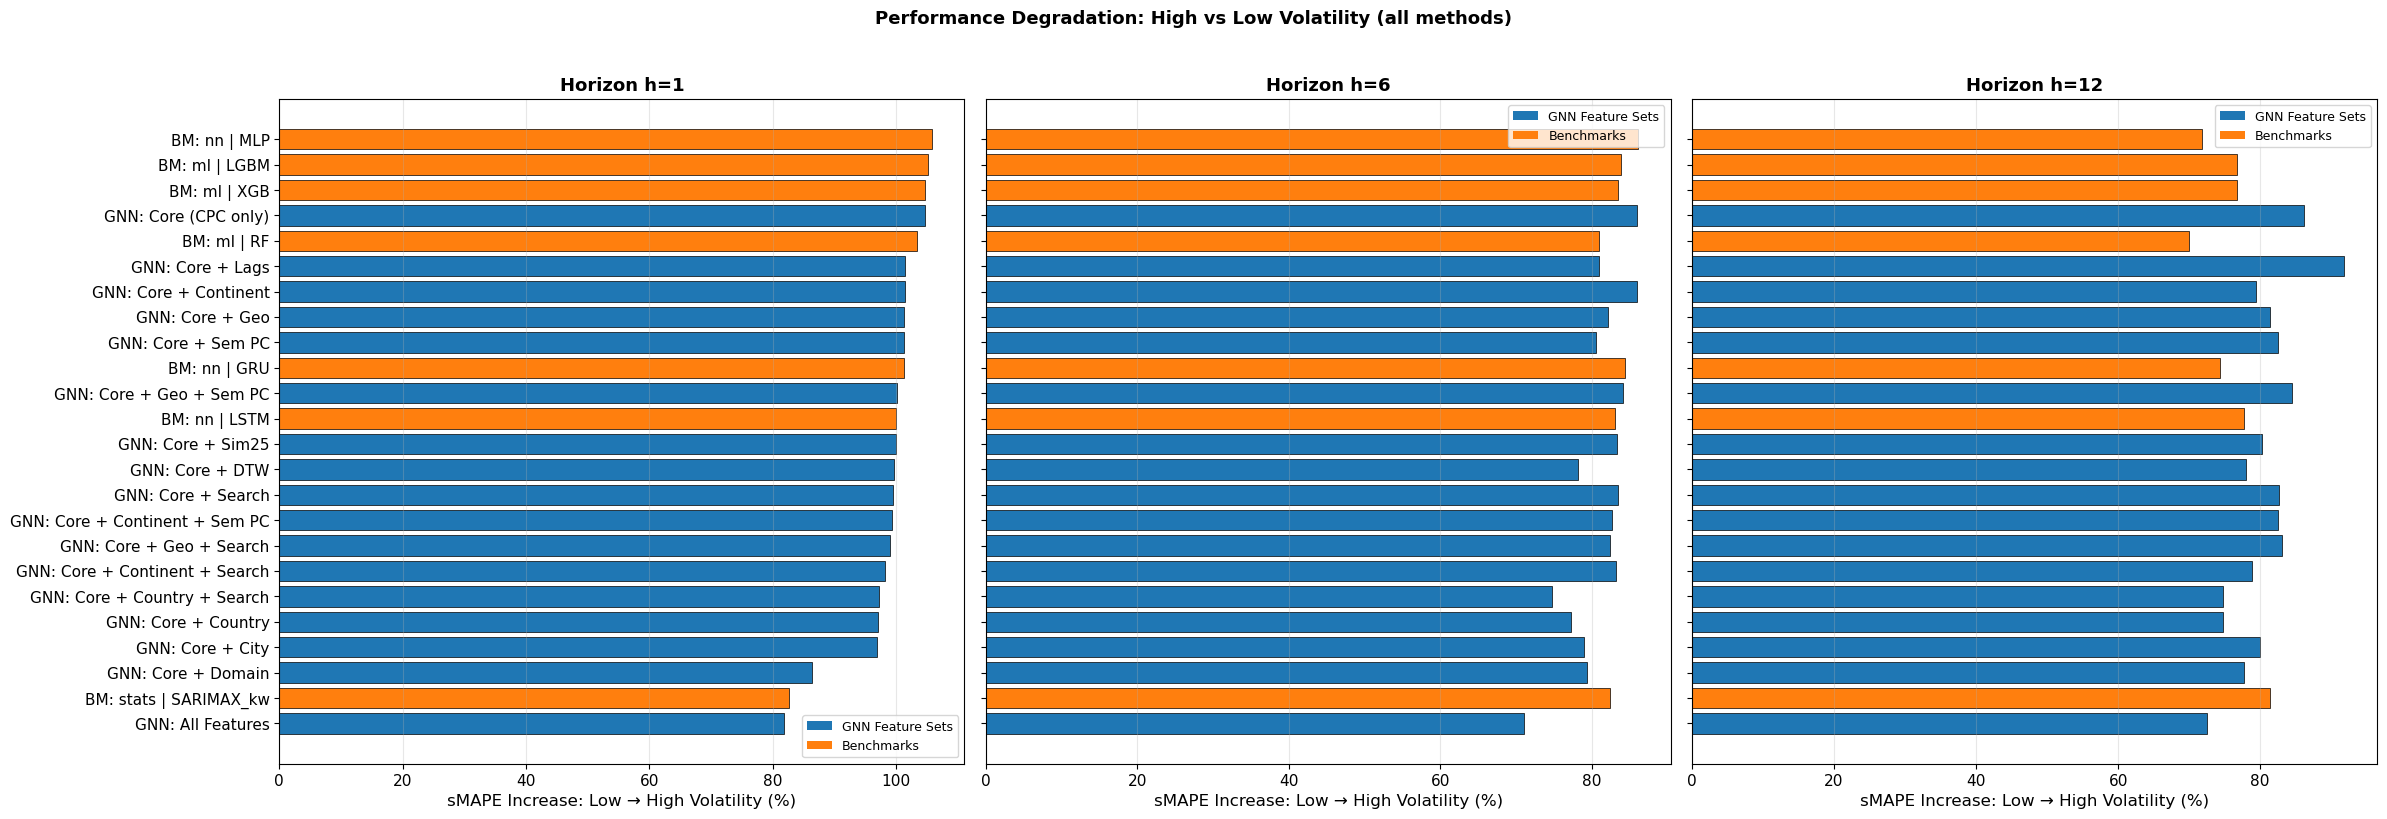

Saved: output/degradation_all_methods.pdf


In [50]:
# =============================================================================
# VIZ 7: Performance Degradation — High vs Low tercile across all methods
# =============================================================================
# How much worse does each method do on High-vol vs Low-vol keywords?
# Includes both GNN feature sets (avg across models) and benchmark baselines.
# =============================================================================

fig, axes = plt.subplots(1, len(horizons), figsize=(8 * len(horizons), 8), sharey=True)
if len(horizons) == 1:
    axes = [axes]

for i, h in enumerate(horizons):
    ax = axes[i]
    deg_rows = []

    # GNN feature sets (avg across models)
    for fs in set_order:
        sub = abl_terc[(abl_terc['horizon'] == h) & (abl_terc['feature_set'] == fs)]
        low_v = sub.loc[sub['segment'] == 'Low', 'sMAPE'].mean()
        high_v = sub.loc[sub['segment'] == 'High', 'sMAPE'].mean()
        if not np.isnan(low_v) and not np.isnan(high_v) and low_v > 0:
            pct = 100.0 * (high_v - low_v) / low_v
            deg_rows.append({
                'method': f"GNN: {FEATURE_SET_LABELS.get(fs, fs)}",
                'pct': pct, 'source': 'GNN'
            })

    # Benchmarks
    if len(bench_terc):
        for model in sorted(bench_terc['model'].unique()):
            sub = bench_terc[(bench_terc['horizon'] == h) & (bench_terc['model'] == model)]
            low_v = sub.loc[sub['segment'] == 'Low', 'sMAPE'].values
            high_v = sub.loc[sub['segment'] == 'High', 'sMAPE'].values
            if len(low_v) and len(high_v) and low_v[0] > 0:
                pct = 100.0 * (high_v[0] - low_v[0]) / low_v[0]
                deg_rows.append({'method': f"BM: {model}", 'pct': pct, 'source': 'BM'})

    deg = pd.DataFrame(deg_rows).sort_values('pct')
    if len(deg):
        colors = ['#1f77b4' if s == 'GNN' else '#ff7f0e' for s in deg['source']]
        ax.barh(deg['method'], deg['pct'], color=colors, edgecolor='black', linewidth=0.5)
        ax.set_xlabel('sMAPE Increase: Low → High Volatility (%)')
        ax.set_title(f'Horizon h={h}', fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#1f77b4', label='GNN Feature Sets'),
                          Patch(facecolor='#ff7f0e', label='Benchmarks')]
        ax.legend(handles=legend_elements, fontsize=9)

figure_path = output_path('degradation_all_methods.pdf')
plt.suptitle('Performance Degradation: High vs Low Volatility (all methods)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figure_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved: {figure_path}")

In [51]:
# =============================================================================
# TABLE 7: Best Method per Segment — GNN Feature Sets vs Benchmarks
# =============================================================================
# For each horizon × segment, who wins?  Shows the single best method.
# =============================================================================

abl_terc = abl_df[abl_df['seg_type'] == 'tercile']
abl_overall = abl_df[abl_df['seg_type'] == 'overall']

print("=" * 90)
print("TABLE 7: Best Method per Segment — GNN (best FS, avg models) vs Benchmarks")
print("=" * 90)

for h in sorted(abl_overall['horizon'].unique()):
    print(f"\n{'─'*90}")
    print(f"  Horizon h={h}")
    print(f"{'─'*90}")

    candidates = []

    # GNN: each feature set averaged across models
    for fs in abl_overall['feature_set'].unique():
        sub_o = abl_overall[(abl_overall['horizon'] == h) & (abl_overall['feature_set'] == fs)]
        if len(sub_o):
            ov = sub_o['sMAPE'].mean()
            label = f"GNN: {FEATURE_SET_LABELS.get(fs, fs)}"

            sub_t = abl_terc[(abl_terc['horizon'] == h) & (abl_terc['feature_set'] == fs)]
            terc_vals = {}
            for terc in ['Low', 'Medium', 'High']:
                vals = sub_t.loc[sub_t['segment'] == terc, 'sMAPE']
                terc_vals[terc] = vals.mean() if len(vals) else np.nan
            candidates.append({'Method': label, 'Overall': ov, **terc_vals})

    # Benchmarks
    if len(bench_terc):
        for model in bench_overall['model'].unique():
            sub_bo = bench_overall[(bench_overall['horizon'] == h) & (bench_overall['model'] == model)]
            if len(sub_bo):
                ov = sub_bo['sMAPE'].values[0]
                sub_bt = bench_terc[(bench_terc['horizon'] == h) & (bench_terc['model'] == model)]
                terc_vals = {}
                for terc in ['Low', 'Medium', 'High']:
                    vals = sub_bt.loc[sub_bt['segment'] == terc, 'sMAPE']
                    terc_vals[terc] = vals.values[0] if len(vals) else np.nan
                candidates.append({'Method': f"BM: {model}", 'Overall': ov, **terc_vals})

    if candidates:
        cdf = pd.DataFrame(candidates).set_index('Method')
        cols = [c for c in ['Low', 'Medium', 'High', 'Overall'] if c in cdf.columns]
        cdf = cdf[cols].sort_values('Overall')

        # Mark the best per column
        print(cdf.round(2).to_string())
        print(f"\n  Best per segment:")
        for col in cols:
            best_method = cdf[col].idxmin()
            print(f"    {col:>10s} -> {best_method} ({cdf.loc[best_method, col]:.1f}%)")

TABLE 7: Best Method per Segment — GNN (best FS, avg models) vs Benchmarks

──────────────────────────────────────────────────────────────────────────────────────────
  Horizon h=1
──────────────────────────────────────────────────────────────────────────────────────────
                                  Low  Medium   High  Overall
Method                                                       
GNN: Core (CPC only)            17.22   25.41  35.25    25.96
GNN: Core + Geo                 17.60   25.53  35.44    26.19
GNN: Core + Search              17.74   25.66  35.39    26.26
GNN: Core + Geo + Search        17.84   25.63  35.50    26.32
GNN: Core + Geo + Sem PC        17.75   25.71  35.53    26.33
GNN: Core + Sem PC              17.67   25.77  35.57    26.34
GNN: Core + Continent           17.69   25.78  35.62    26.36
GNN: Core + Continent + Search  17.94   25.75  35.55    26.41
GNN: Core + Continent + Sem PC  17.92   25.89  35.72    26.51
GNN: Core + Sim25               17.92   25.85 

In [52]:
# =============================================================================
# SUMMARY: Key Findings — Feature Set Analysis
# =============================================================================

abl_terc = abl_df[abl_df['seg_type'] == 'tercile']
abl_overall = abl_df[abl_df['seg_type'] == 'overall']
abl_quad = abl_df[abl_df['seg_type'] == 'quadrant']

print("=" * 80)
print("SUMMARY: Feature Set & Competitive Frontier Analysis")
print("=" * 80)

# 1. Best feature set overall
print("\n1. BEST FEATURE SET (avg across GNN models)")
print("-" * 50)
for h in sorted(abl_overall['horizon'].unique()):
    sub = abl_overall[abl_overall['horizon'] == h]
    fs_perf = sub.groupby('feature_set')['sMAPE'].mean().sort_values()
    best = fs_perf.index[0]
    worst = fs_perf.index[-1]
    print(f"  h={h}: Best  = {FEATURE_SET_LABELS.get(best, best):30s} (sMAPE={fs_perf.iloc[0]:.1f}%)")
    print(f"  {'':>5s} Worst = {FEATURE_SET_LABELS.get(worst, worst):30s} (sMAPE={fs_perf.iloc[-1]:.1f}%)")
    print(f"  {'':>5s} Range = {fs_perf.iloc[-1] - fs_perf.iloc[0]:.1f}pp")

# 2. Feature set impact on High-vol keywords
print("\n2. FEATURE SET IMPACT ON HIGH-VOLATILITY KEYWORDS")
print("-" * 50)
for h in sorted(abl_terc['horizon'].unique()):
    sub = abl_terc[(abl_terc['horizon'] == h) & (abl_terc['segment'] == 'High')]
    fs_perf = sub.groupby('feature_set')['sMAPE'].mean().sort_values()
    best = fs_perf.index[0]
    if 'core_only' in fs_perf.index:
        core = fs_perf['core_only']
        delta = core - fs_perf.iloc[0]
        print(f"  h={h}: Best = {FEATURE_SET_LABELS.get(best, best)}")
        print(f"         Improvement vs Core-Only: {delta:.1f}pp ({100*delta/core:.1f}%)")

# 3. Competitive frontier quadrants: core vs best-combined
print("\n3. COMPETITIVE FRONTIER QUADRANTS: CORE vs BEST-COMBINED")
print("-" * 50)
quad_labels = {
    'Low CPC / Low Vol': 'Low Mean / Low Vol',
    'Low CPC / High Vol': 'Low Mean / High Vol',
    'High CPC / Low Vol': 'High Mean / Low Vol',
    'High CPC / High Vol': 'High Mean / High Vol',
}
target_horizons = [h for h in [6, 12] if h in sorted(abl_quad['horizon'].unique())]
combo_candidates = [fs for fs in COMBO_SETS if fs in abl_quad['feature_set'].unique()]

if combo_candidates and target_horizons:
    best_combo_by_h = {}
    for h in target_horizons:
        combo_perf = (
            abl_overall[
                (abl_overall['horizon'] == h) &
                (abl_overall['feature_set'].isin(combo_candidates))
            ]
            .groupby('feature_set')['sMAPE']
            .mean()
            .sort_values()
        )
        if len(combo_perf):
            best_combo_by_h[h] = combo_perf.index[0]

    if best_combo_by_h:
        print("  Best combined by horizon:")
        for h in target_horizons:
            best_fs = best_combo_by_h.get(h)
            if best_fs is not None:
                print(f"    h={h}: {FEATURE_SET_LABELS.get(best_fs, best_fs)}")

        quad_rows = []
        for quad in quadrant_order:
            row = {'Quadrant': quad_labels.get(quad, quad)}
            for h in target_horizons:
                best_fs = best_combo_by_h.get(h)
                best_fs_label = FEATURE_SET_LABELS.get(best_fs, best_fs) if best_fs is not None else '-'
                core_val = abl_quad[
                    (abl_quad['horizon'] == h) &
                    (abl_quad['feature_set'] == 'core_only') &
                    (abl_quad['segment'] == quad)
                ]['sMAPE'].mean()
                combo_val = np.nan
                if best_fs is not None:
                    combo_val = abl_quad[
                        (abl_quad['horizon'] == h) &
                        (abl_quad['feature_set'] == best_fs) &
                        (abl_quad['segment'] == quad)
                    ]['sMAPE'].mean()
                row[f'h={h} Best FS'] = best_fs_label
                row[f'h={h} Core'] = core_val
                row[f'h={h} Best-Combined'] = combo_val
                row[f'h={h} Δ'] = combo_val - core_val
            quad_rows.append(row)

        quad_table = pd.DataFrame(quad_rows).set_index('Quadrant')
        print("\n  Δ = Best-Combined - Core (negative is better)")
        print(quad_table.round(2).to_string())
        quad_table.to_csv('quadrant_core_vs_best_combined_h6_h12.csv')
        print("\n  Saved: quadrant_core_vs_best_combined_h6_h12.csv")
    else:
        print("  No combined feature-set results available for h=6/h=12.")
else:
    print("  No combined feature-set data available.")

# 4. Volatility gap by feature set
print("\n4. HIGH/LOW VOLATILITY GAP BY FEATURE SET")
print("-" * 50)
for h in sorted(abl_terc['horizon'].unique()):
    gap_rows = []
    for fs in set_order:
        sub = abl_terc[(abl_terc['horizon'] == h) & (abl_terc['feature_set'] == fs)]
        low_v = sub.loc[sub['segment'] == 'Low', 'sMAPE'].mean()
        high_v = sub.loc[sub['segment'] == 'High', 'sMAPE'].mean()
        if not np.isnan(low_v) and not np.isnan(high_v):
            gap_rows.append({'fs': fs, 'gap': high_v - low_v, 'ratio': high_v / low_v})
    gaps = pd.DataFrame(gap_rows).set_index('fs').sort_values('gap')
    best_gap = gaps.index[0]
    worst_gap = gaps.index[-1]
    print(f"  h={h}: Smallest gap  = {FEATURE_SET_LABELS.get(best_gap, best_gap)} "
          f"(Δ={gaps.iloc[0]['gap']:.1f}pp, ratio={gaps.iloc[0]['ratio']:.2f}x)")
    print(f"         Largest gap   = {FEATURE_SET_LABELS.get(worst_gap, worst_gap)} "
          f"(Δ={gaps.iloc[-1]['gap']:.1f}pp, ratio={gaps.iloc[-1]['ratio']:.2f}x)")

# 5. GNN vs benchmarks
print("\n5. GNN vs BENCHMARK BASELINES")
print("-" * 50)
if len(df_bench_seg):
    for h in sorted(abl_overall['horizon'].unique()):
        # Best GNN
        fs_perf = abl_overall[abl_overall['horizon'] == h].groupby('feature_set')['sMAPE'].mean()
        best_gnn = fs_perf.min()
        best_gnn_fs = fs_perf.idxmin()

        # Best benchmark
        bm_ov = bench_overall[bench_overall['horizon'] == h]
        if len(bm_ov):
            best_bm = bm_ov['sMAPE'].min()
            best_bm_model = bm_ov.loc[bm_ov['sMAPE'].idxmin(), 'model']
            delta = best_bm - best_gnn
            winner = 'GNN' if best_gnn < best_bm else 'Benchmark'
            print(f"  h={h}: GNN best = {FEATURE_SET_LABELS.get(best_gnn_fs, best_gnn_fs)} ({best_gnn:.1f}%)")
            print(f"         BM best  = {best_bm_model} ({best_bm:.1f}%)")
            print(f"         Winner: {winner} (Δ={abs(delta):.1f}pp)")
else:
    print("  No benchmark data available.")

# 6. Coverage
print(f"\n\nDATA COVERAGE")
print("-" * 50)
print(f"  GNN tensor experiments: {len(df_results['feature_set'].unique())} feature sets")
print(f"  GNN models: {sorted(abl_df['model'].unique())}")
print(f"  Horizons: {sorted(abl_df['horizon'].unique())}")
if len(df_bench_seg):
    print(f"  Benchmark models: {sorted(df_bench_seg['model'].unique())}")
print(f"  Total df_results rows: {len(df_results)}")

# 7. Detailed CSV exports by segment family
print("\n7. DETAILED CSV EXPORTS")
print("-" * 50)
export_cols = [
    'exp_group', 'experiment', 'feature_set', 'feature_set_label',
    'model', 'horizon', 'seg_type', 'segment',
    'RMSE', 'MAE', 'sMAPE', 'med_node_RMSE', 'n_keywords'
]
export_cols = [c for c in export_cols if c in abl_df.columns]

terc_export = (
    abl_terc[export_cols]
    .sort_values(['horizon', 'segment', 'feature_set', 'model'])
    .reset_index(drop=True)
)
quad_export = (
    abl_quad[export_cols]
    .sort_values(['horizon', 'segment', 'feature_set', 'model'])
    .reset_index(drop=True)
)

terc_export_path = 'competitive_frontier_results_tercile_detailed.csv'
quad_export_path = 'competitive_frontier_results_quadrant_detailed.csv'
terc_export.to_csv(terc_export_path, index=False)
quad_export.to_csv(quad_export_path, index=False)

print(f"  Saved: {terc_export_path} ({len(terc_export)} rows)")
print(f"  Saved: {quad_export_path} ({len(quad_export)} rows)")
print("  Contents: all feature sets, all GNN models, all available metrics.")

# Save final combined data
df_results.to_csv('competitive_frontier_results.csv', index=False)
print(f"\nSaved: competitive_frontier_results.csv")

SUMMARY: Feature Set & Competitive Frontier Analysis

1. BEST FEATURE SET (avg across GNN models)
--------------------------------------------------
  h=1: Best  = Core (CPC only)                (sMAPE=26.0%)
        Worst = All Features                   (sMAPE=29.3%)
        Range = 3.3pp
  h=6: Best  = Core + Geo + Sem PC            (sMAPE=30.7%)
        Worst = All Features                   (sMAPE=34.0%)
        Range = 3.3pp
  h=12: Best  = Core + Continent               (sMAPE=37.9%)
        Worst = All Features                   (sMAPE=43.1%)
        Range = 5.2pp

2. FEATURE SET IMPACT ON HIGH-VOLATILITY KEYWORDS
--------------------------------------------------
  h=1: Best = Core (CPC only)
         Improvement vs Core-Only: 0.0pp (0.0%)
  h=6: Best = Core + Geo + Sem PC
         Improvement vs Core-Only: 1.3pp (3.1%)
  h=12: Best = Core + Continent + Search
         Improvement vs Core-Only: 1.2pp (2.4%)

3. COMPETITIVE FRONTIER QUADRANTS: CORE vs BEST-COMBINED
------------

In [54]:
# =============================================================================
# EXPORT: One Row per Model and Feature Set
# =============================================================================
# Uses only the overall rows and pivots horizons into columns so the final CSV
# has one row per (model, feature_set).
# =============================================================================

overall_export = abl_df[abl_df['seg_type'] == 'overall'].copy()

id_cols = ['exp_group', 'experiment', 'feature_set', 'feature_set_label', 'model']
id_cols = [c for c in id_cols if c in overall_export.columns]
metric_cols = ['RMSE', 'MAE', 'sMAPE', 'med_node_RMSE', 'n_keywords']
metric_cols = [c for c in metric_cols if c in overall_export.columns]

wide_parts = []
for metric in metric_cols:
    metric_wide = overall_export.pivot_table(
        index=id_cols,
        columns='horizon',
        values=metric,
        aggfunc='first'
    )
    metric_wide = metric_wide.rename(columns=lambda h: f'{metric}_h{int(h)}')
    wide_parts.append(metric_wide)

model_featureset_export = pd.concat(wide_parts, axis=1).reset_index()
model_featureset_export = model_featureset_export.sort_values(['feature_set', 'model']).reset_index(drop=True)

model_featureset_export_path = 'competitive_frontier_results_model_featureset.csv'
model_featureset_export.to_csv(model_featureset_export_path, index=False)

print(f"Saved: {model_featureset_export_path} ({len(model_featureset_export)} rows)")
print("Contents: one row per model and feature set, overall results only, metrics split into horizon-specific columns.")

Saved: competitive_frontier_results_model_featureset.csv (84 rows)
Contents: one row per model and feature set, overall results only, metrics split into horizon-specific columns.


In [56]:
df_results.to_csv('competitive_frontier_results_full.csv', index=False)
df_results['model'].unique()

array(['AGCRN', 'DCRNN', 'GConvLSTM', 'GraphWaveNet', 'A3TGCN', 'MTGNN',
       'STConv', 'STGCN'], dtype=object)